In [8]:
from pathlib import Path
import pandas as pd

STATIC_PARAMETERS = {"RecordID", "Age", "Gender", "Height", "ICUType", "Weight"}
STATIC_EXCLUDE = {"RecordID", "Age", "Gender", "Height", "ICUType"}

def hhmm_to_minutes(value: str) -> int:
    hours, minutes = value.split(":")
    return int(hours) * 60 + int(minutes)

def parse_patient_file(file_path: Path):
    df = pd.read_csv(file_path)
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

    record_rows = df.loc[df["Parameter"] == "RecordID", "Value"].dropna()
    patient_id = int(record_rows.iloc[0]) if not record_rows.empty else int(file_path.stem)

    static_df = df[df["Parameter"].isin(STATIC_PARAMETERS)].copy()
    static_df = static_df.drop_duplicates(subset=["Parameter"], keep="last")
    static_values = static_df.set_index("Parameter")["Value"].to_dict()

    static_record = {
        "RecordID": patient_id,
        "Age": static_values.get("Age"),
        "Gender": static_values.get("Gender"),
        "Height": static_values.get("Height"),
        "Weight": static_values.get("Weight"),
        "ICUType": static_values.get("ICUType"),
    }

    dynamic_df = df[~df["Parameter"].isin(STATIC_EXCLUDE)].copy()
    dynamic_df["Minutes"] = dynamic_df["Time"].map(hhmm_to_minutes)
    dynamic_df["RecordID"] = patient_id
    dynamic_df = dynamic_df[["RecordID", "Time", "Minutes", "Parameter", "Value"]]

    return static_record, dynamic_df

def load_cohort(folder: str):
    folder_path = Path(folder)
    static_records = []
    dynamic_tables = []

    for file_path in sorted(folder_path.glob("*.txt")):
        static_record, dynamic_df = parse_patient_file(file_path)
        static_records.append(static_record)
        dynamic_tables.append(dynamic_df)

    patients_static = pd.DataFrame(static_records).drop_duplicates(subset=["RecordID"])
    patients_static = patients_static.set_index("RecordID").sort_index()

    if dynamic_tables:
        patient_events = pd.concat(dynamic_tables, ignore_index=True)
        patient_events = patient_events.sort_values(["RecordID", "Minutes", "Parameter"]).reset_index(drop=True)
    else:
        patient_events = pd.DataFrame(columns=["RecordID", "Time", "Minutes", "Parameter", "Value"])

    return patients_static, patient_events

In [9]:
train_data_location = "set-a"
patients_static, patient_events = load_cohort(train_data_location)

print(f"Number of patients: {patients_static.shape[0]}")
print(f"Number of dynamic observations: {patient_events.shape[0]}")

display(patients_static.head())
display(patient_events.head(15))

Number of patients: 4000
Number of dynamic observations: 1737980


,Age,Gender,Height,Weight,ICUType
RecordID,,,,,
132539,54.0,0.0,-1.0,-1.0,4.0
132540,76.0,1.0,175.3,81.6,2.0
132541,44.0,0.0,-1.0,56.7,3.0
132543,68.0,1.0,180.3,84.6,3.0
132545,88.0,0.0,-1.0,-1.0,3.0


,RecordID,Time,Minutes,Parameter,Value
0,132539,00:00,0,Weight,-1.00
1,132539,00:07,7,GCS,15.00
2,132539,00:07,7,HR,73.00
3,132539,00:07,7,NIDiasABP,65.00
4,132539,00:07,7,NIMAP,92.33
5,132539,00:07,7,NISysABP,147.00
6,132539,00:07,7,RespRate,19.00
7,132539,00:07,7,Temp,35.10
8,132539,00:07,7,Urine,900.00
9,132539,00:37,37,HR,77.00


In [10]:
#create a pivot table of patient_events
pivot_table = patient_events.pivot_table(index=["RecordID", "Time", "Minutes"], columns="Parameter", values="Value")
print("Pivot table of patient_events:")
# display(pivot_table.head(5))
#find how many columns are in the pivot table
print(f"Number of columns in the pivot table: {pivot_table.shape[1]}")
#make it a dataframe again
pivot_table = pivot_table.reset_index()
print("Pivot table of patient_events after resetting index:")
# display(pivot_table.head(5))
#join the static variables to the pivot table
pivot_table = pivot_table.merge(patients_static, on="RecordID", how="left")
pivot_table = pivot_table.sort_values(["RecordID", "Minutes"]).reset_index(drop=True)
print("Pivot table of patient_events after merging with patients_static:")
# display(pivot_table.head(5))
#values that gender variable can take
print(f"Unique values in Gender column: {pivot_table['Gender'].unique()}")
#minus one for the 'Gender' 0,1,-1
print(f"Number of columns in the pivot table after merging with patients_static: {pivot_table.shape[1]}")
print(f"pivot table columns: {pivot_table.columns.tolist()}")

Pivot table of patient_events:
Number of columns in the pivot table: 37
Pivot table of patient_events after resetting index:
Pivot table of patient_events after merging with patients_static:
Unique values in Gender column: [ 0.  1. -1.]
Number of columns in the pivot table after merging with patients_static: 45
pivot table columns: ['RecordID', 'Time', 'Minutes', 'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight_x', 'pH', 'Age', 'Gender', 'Height', 'Weight_y', 'ICUType']


In [11]:
pivot_table

,RecordID,Time,Minutes,ALP,ALT,AST,Albumin,BUN,Bilirubin,Cholesterol,...,TroponinT,Urine,WBC,Weight_x,pH,Age,Gender,Height,Weight_y,ICUType
0,132539,00:00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-1.0,NaN,54.0,0.0,-1.0,-1.0,4.0
1,132539,00:07,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,900.0,NaN,NaN,NaN,54.0,0.0,-1.0,-1.0,4.0
2,132539,00:37,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,60.0,NaN,NaN,NaN,54.0,0.0,-1.0,-1.0,4.0
3,132539,01:37,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,30.0,NaN,NaN,NaN,54.0,0.0,-1.0,-1.0,4.0
4,132539,02:37,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,170.0,NaN,NaN,NaN,54.0,0.0,-1.0,-1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299259,142673,45:36,2736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,23.0,NaN,87.3,NaN,78.0,0.0,157.5,87.3,4.0
299260,142673,45:39,2739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.31,78.0,0.0,157.5,87.3,4.0
299261,142673,46:36,2796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,40.0,NaN,87.3,NaN,78.0,0.0,157.5,87.3,4.0
299262,142673,47:21,2841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,87.3,NaN,78.0,0.0,157.5,87.3,4.0


In [12]:
#find unique parameters in patient_events
unique_parameters = patient_events["Parameter"].unique()
print(f"Unique parameters in patient_events: {unique_parameters}")
print(f"length of unique parameters: {len(unique_parameters)}")

Unique parameters in patient_events: ['Weight' 'GCS' 'HR' 'NIDiasABP' 'NIMAP' 'NISysABP' 'RespRate' 'Temp'
 'Urine' 'HCT' 'BUN' 'Creatinine' 'Glucose' 'HCO3' 'K' 'Mg' 'Na'
 'Platelets' 'WBC' 'PaCO2' 'PaO2' 'pH' 'DiasABP' 'FiO2' 'MAP' 'MechVent'
 'SysABP' 'SaO2' 'ALP' 'ALT' 'AST' 'Albumin' 'Bilirubin' 'Lactate'
 'Cholesterol' 'TroponinI' 'TroponinT']
length of unique parameters: 37


In [13]:
# load in outcomes for the training set (set-a)
outcomes = pd.read_csv("Outcomes-a.txt")
print(f"Number of outcome records: {outcomes.shape[0]}")
#number of null records
num_null_records = outcomes['In-hospital_death'].isnull().sum()
print(f"Number of null records in 'In-hospital_death': {num_null_records}")
outcomes#[['In-hospital_death']]

Number of outcome records: 4000
Number of null records in 'In-hospital_death': 0


,RecordID,SAPS-I,SOFA,Length_of_stay,Survival,In-hospital_death
0,132539,6,1,5,-1,0
1,132540,16,8,8,-1,0
2,132541,21,11,19,-1,0
3,132543,7,1,9,575,0
4,132545,17,2,4,918,0
...,...,...,...,...,...,...
3995,142665,19,7,10,336,0
3996,142667,8,2,3,-1,0
3997,142670,8,5,11,-1,0
3998,142671,22,10,8,7,1


## Q1.1: Build Regular Hourly Time Grid

Convert irregularly-sampled events into a regular 49-step hourly grid (00:00–48:00).

**Rounding:** ceiling — a measurement at minute 37 goes into hour 1 (the first hour boundary at which we *know* that value), preserving temporal causality.

**Multiple values in same hour:** keep the last (most recent within that hour).

**Missing values:** filled with NaN for now (forward-fill in Q1.3).

In [14]:
import numpy as np
import math

DYNAMIC_VARS = sorted([
    'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol',
    'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT',
    'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP',
    'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2',
    'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH'
])  # 37 dynamic variables (Weight remains dynamic)

# Add StaticWeight as a separate static field
STATIC_VARS = ['Age', 'Gender', 'Height', 'StaticWeight', 'ICUType']

HOURS = list(range(49))  # hour slots 0..48  (00:00 to 48:00)


def build_hourly_grid(patients_static, patient_events):
    """
    Convert irregularly-sampled patient events into a regular 49-step hourly grid.

    Rounding: ceiling — minute 0 → hour 0, minute 1..60 → hour 1, etc.
    Multiple measurements for the same variable in the same hour: keep the last.
    Missing values are NaN (forward-fill later if desired).
    Static variables (including StaticWeight) are broadcast to all 49 rows.
    Weight is treated as a dynamic variable.
    """
    # Copy to avoid mutating caller; create StaticWeight snapshot from admission Weight
    ps = patients_static.copy()
    ps['StaticWeight'] = ps['Weight']

    df = patient_events.copy()

    # Ceiling: minute 0 → 0, minute 1..60 → 1, minute 61..120 → 2, ...
    df["hour"] = df["Minutes"].apply(lambda m: math.ceil(m / 60))

    # Discard anything beyond the 48h window
    df = df[df["hour"] <= 48]

    # Last measurement per (patient, hour, variable)
    df_last = (
        df.sort_values(["RecordID", "Minutes"])
          .groupby(["RecordID", "hour", "Parameter"])["Value"]
          .last()
          .unstack("Parameter")
    )

    # Ensure all dynamic cols exist
    for col in DYNAMIC_VARS:
        if col not in df_last.columns:
            df_last[col] = np.nan
    df_last = df_last[DYNAMIC_VARS]

    # Full grid: every patient × every hour 0..48
    all_patients = ps.index
    full_index = pd.MultiIndex.from_product([all_patients, HOURS], names=["RecordID", "hour"])
    grid = df_last.reindex(full_index).reset_index()

    # Broadcast statics (including StaticWeight)
    for col in STATIC_VARS:
        grid[col] = ps[col].reindex(grid["RecordID"]).values

    return grid[["RecordID", "hour"] + DYNAMIC_VARS + STATIC_VARS]


print("build_hourly_grid() defined.")
print(f"  Dynamic variables ({len(DYNAMIC_VARS)}): {DYNAMIC_VARS}")
print(f"  Static variables  ({len(STATIC_VARS)}): {STATIC_VARS}")
print(f"  Total data columns: {len(DYNAMIC_VARS) + len(STATIC_VARS)}")

build_hourly_grid() defined.
  Dynamic variables (37): ['ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH']
  Static variables  (5): ['Age', 'Gender', 'Height', 'StaticWeight', 'ICUType']
  Total data columns: 42


In [15]:
SETS = {
    "a": ("set-a", "Outcomes-a.txt"),
    "b": ("set-b", "Outcomes-b.txt"),
    "c": ("set-c", "Outcomes-c.txt"),
}

Path("processed").mkdir(exist_ok=True)

for split, (folder, outcomes_file) in SETS.items():
    print(f"\n--- Processing set-{split} ---")

    # Load raw data
    patients_static, patient_events = load_cohort(folder)
    print(f"  Patients: {len(patients_static)},  Events: {len(patient_events)}")

    # Build hourly grid
    grid = build_hourly_grid(patients_static, patient_events)
    expected_rows = len(patients_static) * 49
    print(f"  Grid shape: {grid.shape}  (expected {expected_rows} rows × {2 + len(DYNAMIC_VARS) + len(STATIC_VARS)} cols)")

    # Load and merge labels
    outcomes = pd.read_csv(outcomes_file)[["RecordID", "In-hospital_death"]]
    grid = grid.merge(outcomes, on="RecordID", how="left")

    # Save to parquet
    out_path = f"processed/set_{split}.parquet"
    grid.to_parquet(out_path, index=False)

    mortality_rate = grid.drop_duplicates("RecordID")["In-hospital_death"].mean()
    print(f"  Saved → {out_path}")
    print(f"  Mortality rate: {mortality_rate:.3f}")


--- Processing set-a ---
  Patients: 4000,  Events: 1737980
  Grid shape: (196000, 44)  (expected 196000 rows × 44 cols)
  Saved → processed/set_a.parquet
  Mortality rate: 0.139

--- Processing set-b ---
  Patients: 4000,  Events: 1742535
  Grid shape: (196000, 44)  (expected 196000 rows × 44 cols)
  Saved → processed/set_b.parquet
  Mortality rate: 0.142

--- Processing set-c ---
  Patients: 4000,  Events: 1745303
  Grid shape: (196000, 44)  (expected 196000 rows × 44 cols)
  Saved → processed/set_c.parquet
  Mortality rate: 0.146


In [16]:
# Sanity check: reload set-a and inspect
df_a = pd.read_parquet("processed/set_a.parquet")

print(f"Shape: {df_a.shape}")
print(f"Columns ({len(df_a.columns)}): {df_a.columns.tolist()}")
print(f"\nRows per patient (should all be 49): {df_a.groupby('RecordID').size().unique().tolist()}")
print(f"\nMissing values (% of total rows), top 10 most sparse:")
print((df_a[DYNAMIC_VARS].isna().mean() * 100).sort_values(ascending=False).head(10).round(1).to_string())

# Show one patient's grid
sample_id = df_a["RecordID"].iloc[0]
print(f"\nSample patient {sample_id} — first 5 hours:")
display(df_a[df_a["RecordID"] == sample_id][["RecordID", "hour", "HR", "Temp", "Age", "Gender", "Urine", "NIDiasABP","In-hospital_death"]].head(6))

Shape: (196000, 45)
Columns (45): ['RecordID', 'hour', 'ALP', 'ALT', 'AST', 'Albumin', 'BUN', 'Bilirubin', 'Cholesterol', 'Creatinine', 'DiasABP', 'FiO2', 'GCS', 'Glucose', 'HCO3', 'HCT', 'HR', 'K', 'Lactate', 'MAP', 'MechVent', 'Mg', 'NIDiasABP', 'NIMAP', 'NISysABP', 'Na', 'PaCO2', 'PaO2', 'Platelets', 'RespRate', 'SaO2', 'SysABP', 'Temp', 'TroponinI', 'TroponinT', 'Urine', 'WBC', 'Weight', 'pH', 'Age', 'Gender', 'Height', 'StaticWeight', 'ICUType', 'In-hospital_death']

Rows per patient (should all be 49): [49]

Missing values (% of total rows), top 10 most sparse:
Cholesterol    99.8
TroponinI      99.8
TroponinT      98.9
Albumin        98.8
ALP            98.4
ALT            98.4
AST            98.4
Bilirubin      98.4
Lactate        96.0
SaO2           96.0

Sample patient 132539 — first 5 hours:


,RecordID,hour,HR,Temp,Age,Gender,Urine,NIDiasABP,In-hospital_death
0,132539,0,NaN,NaN,54.0,0.0,NaN,NaN,0
1,132539,1,77.0,35.6,54.0,0.0,60.0,58.0,0
2,132539,2,60.0,NaN,54.0,0.0,30.0,62.0,0
3,132539,3,62.0,NaN,54.0,0.0,170.0,52.0,0
4,132539,4,80.0,37.8,54.0,0.0,60.0,52.0,0
5,132539,5,74.0,NaN,54.0,0.0,NaN,NaN,0


## 1.2 Age filtering
We filter the age in 10 year bins to spot the differences. There are no patients younger than 10 and older than 100.

                  ALP          ALT          AST   Albumin        BUN  \
age_bin                                                                
[10, 20)   114.781250  1225.000000   867.606061  3.095652  12.384615   
[20, 30)    79.500000  1629.077778  1364.888889  3.140351  16.440120   
[30, 40)   118.909605   970.132597   900.116667  2.938462  19.224436   
[40, 50)   121.547253   352.229958   538.816842  2.887000  22.715561   
[50, 60)   120.564924   273.556837   481.741408  2.986792  27.099534   
[60, 70)   114.875926   361.991023   588.541367  2.868075  27.805807   
[70, 80)   109.508972   220.809984   312.323151  2.899366  29.715938   
[80, 90)   115.375610   153.218750   211.448441  2.898656  31.799486   
[90, 100)  194.030612    73.000000    91.852941  2.871429  36.275416   

           Bilirubin  Cholesterol  Creatinine    DiasABP      FiO2  ...  \
age_bin                                                             ...   
[10, 20)    2.743333          NaN    1.126724  66.802581 

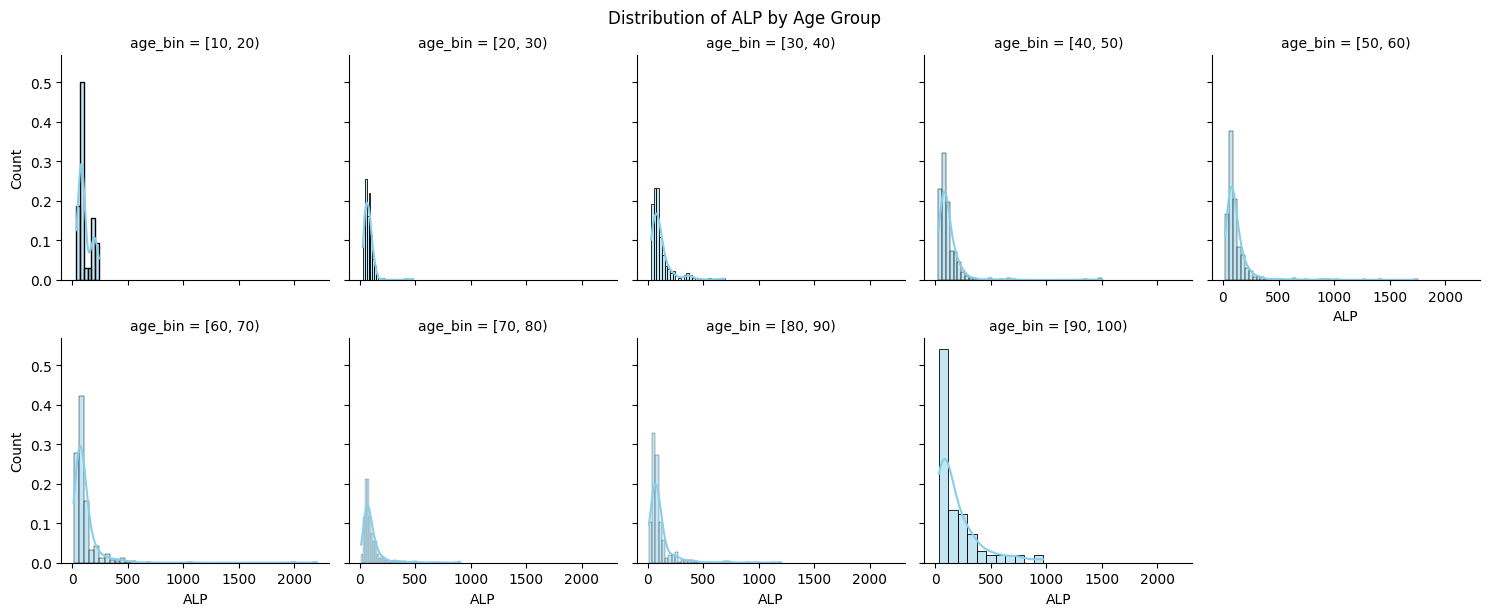

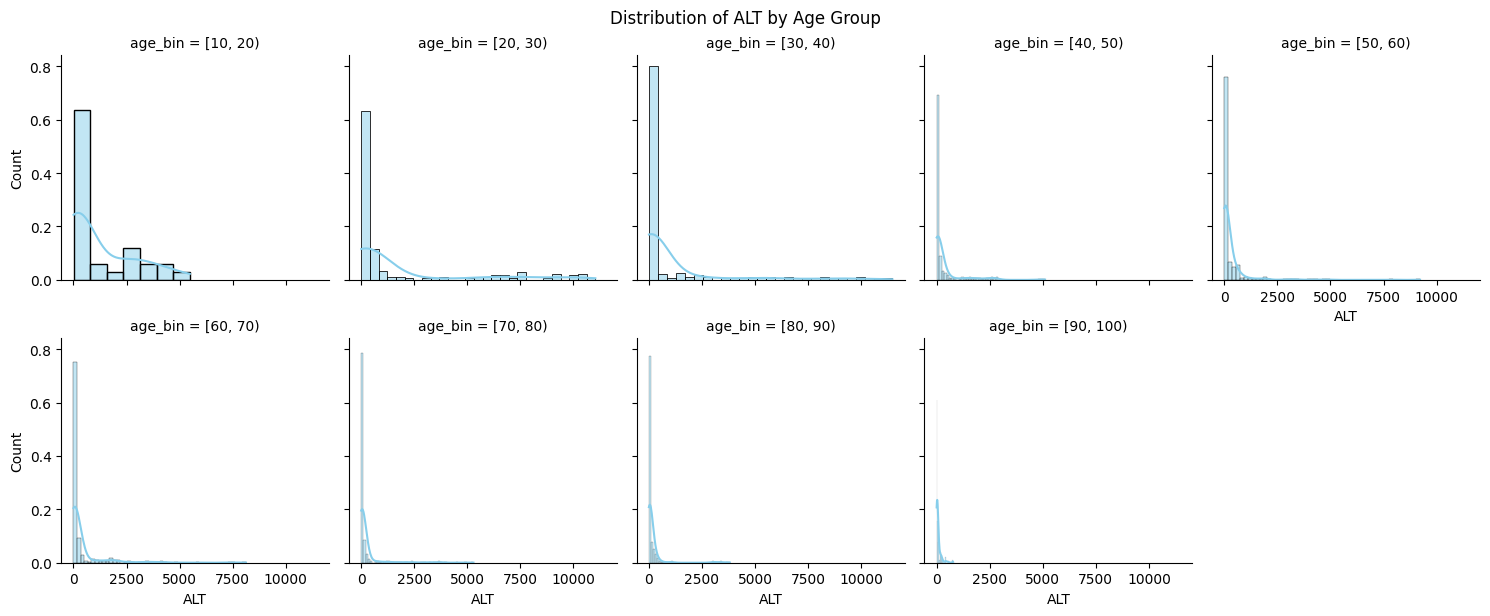

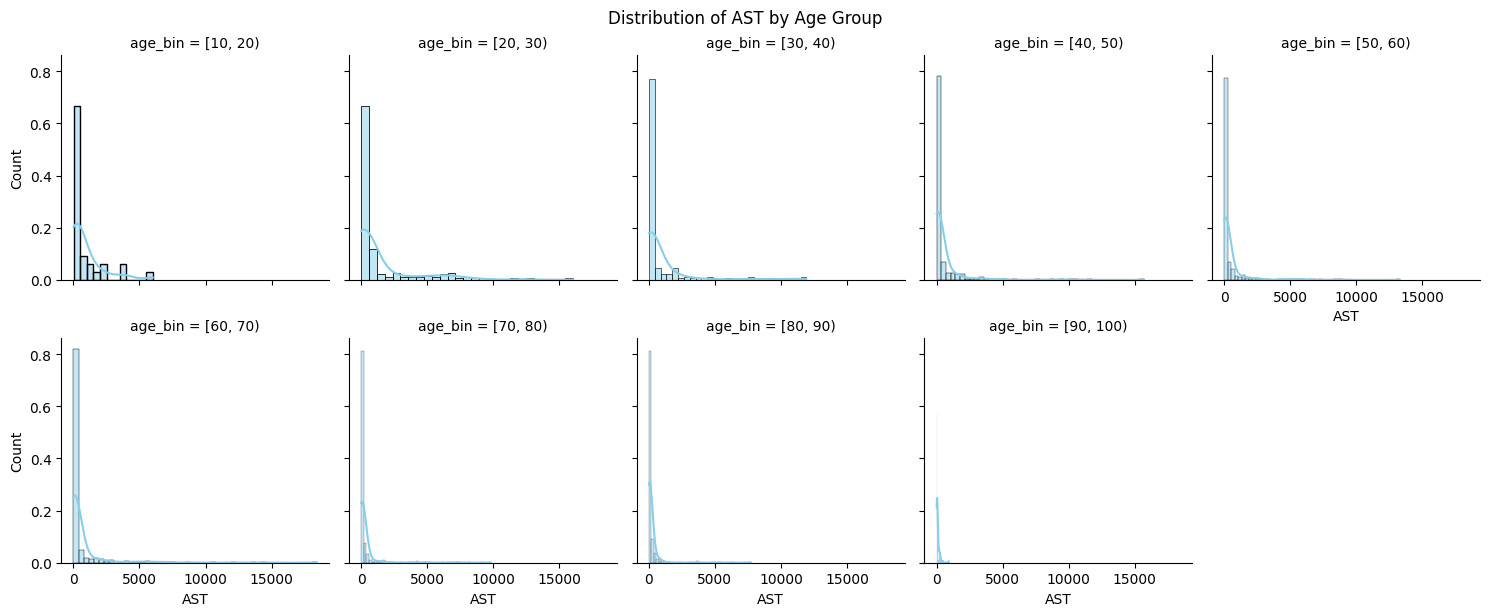

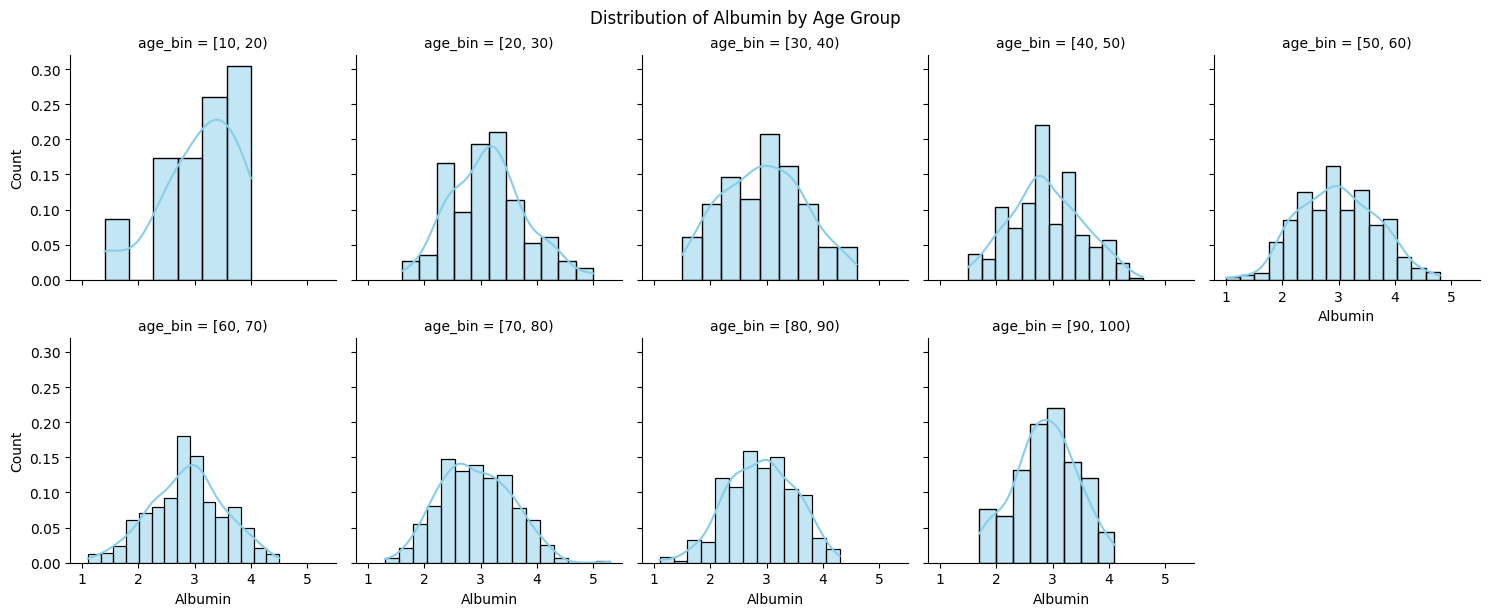

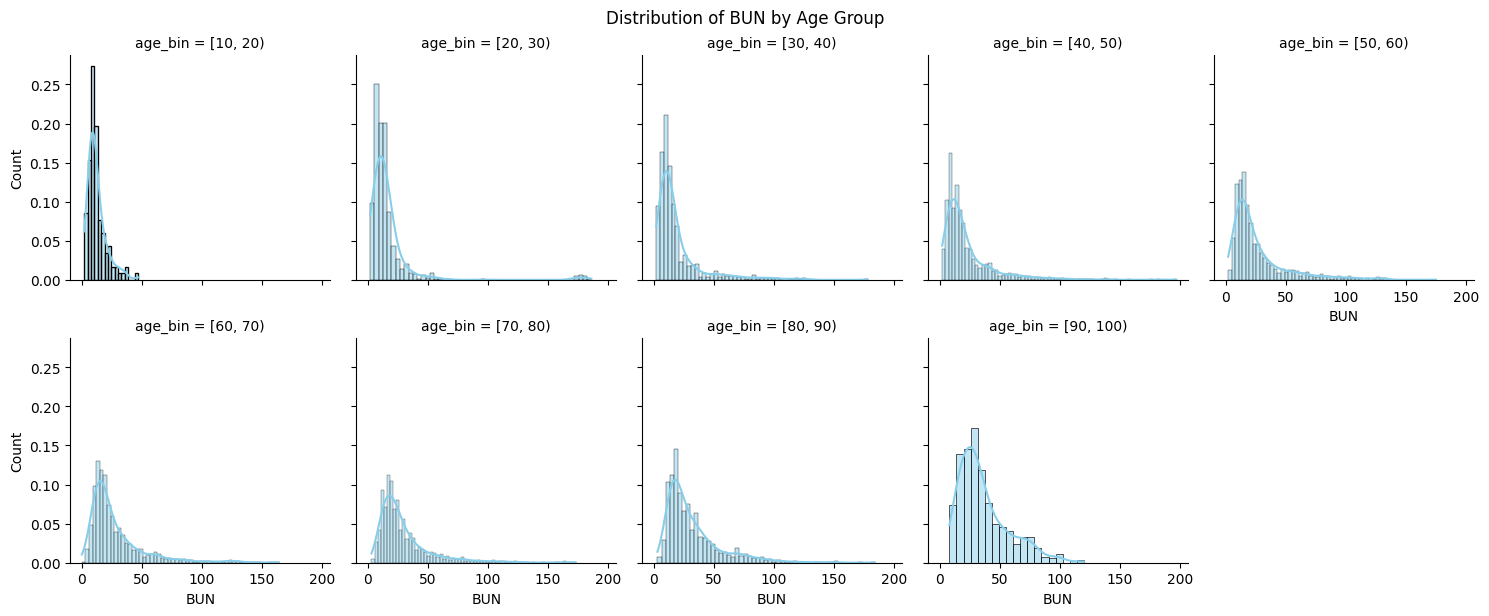

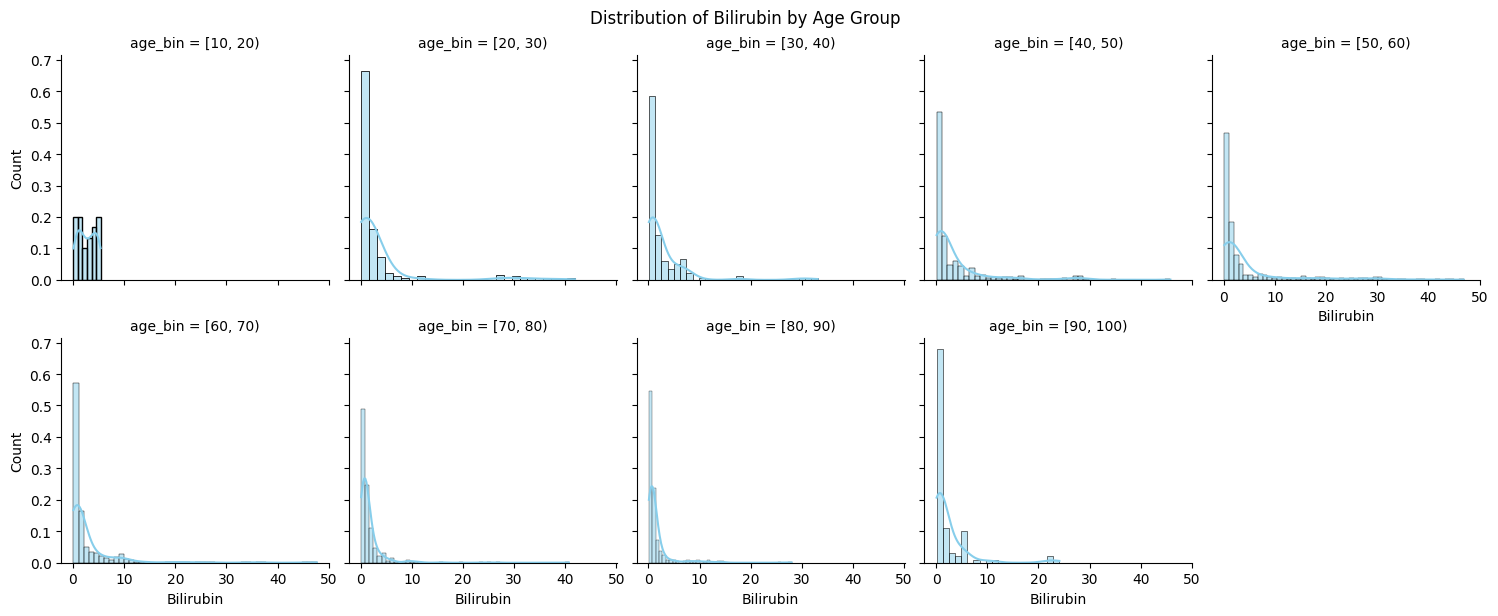

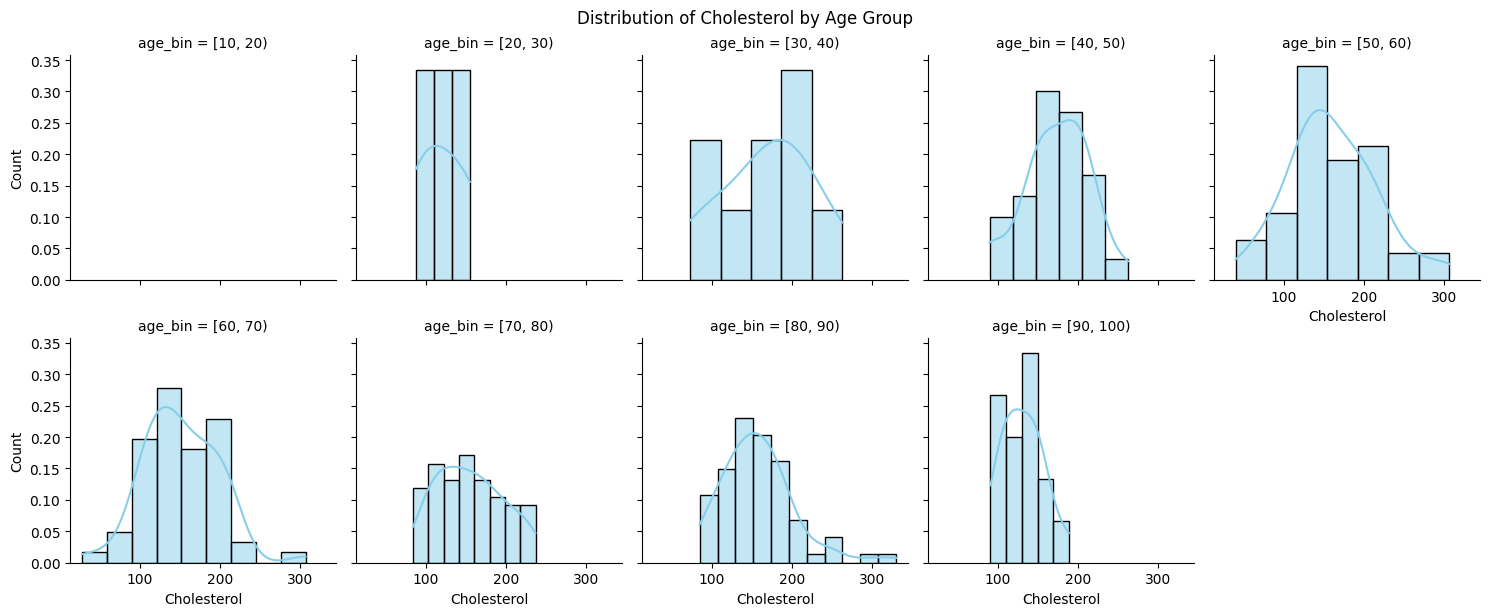

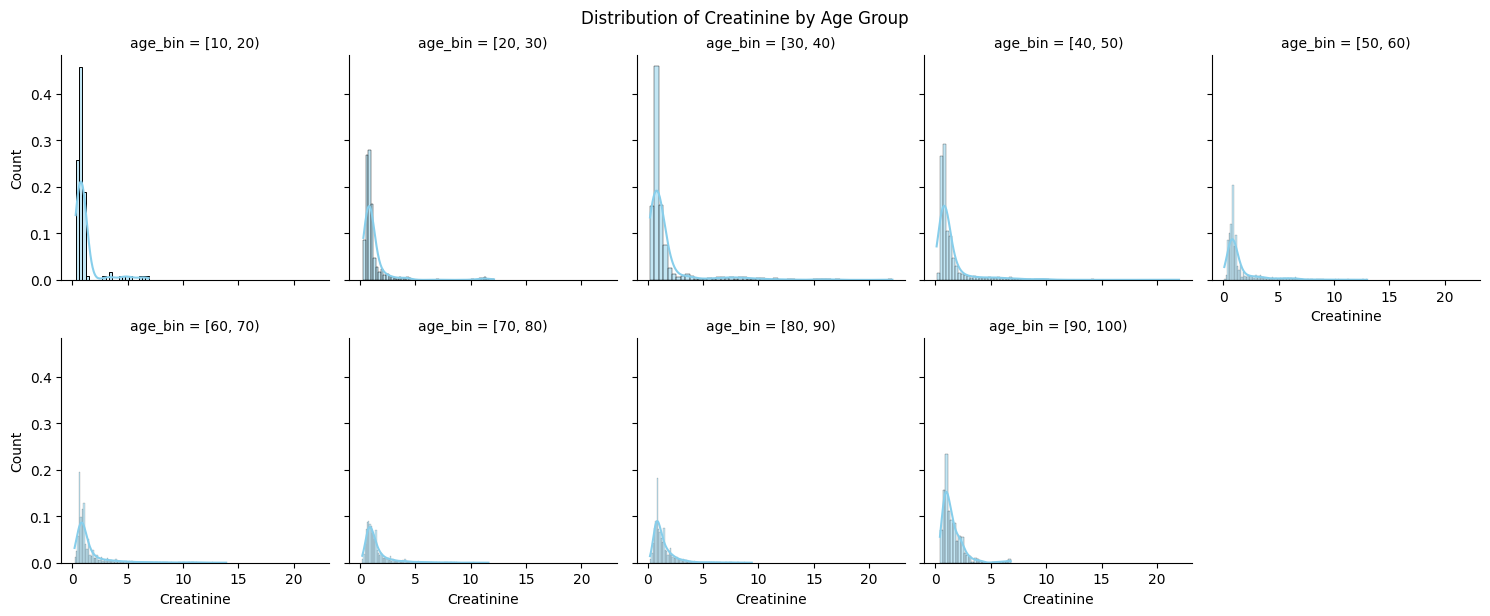

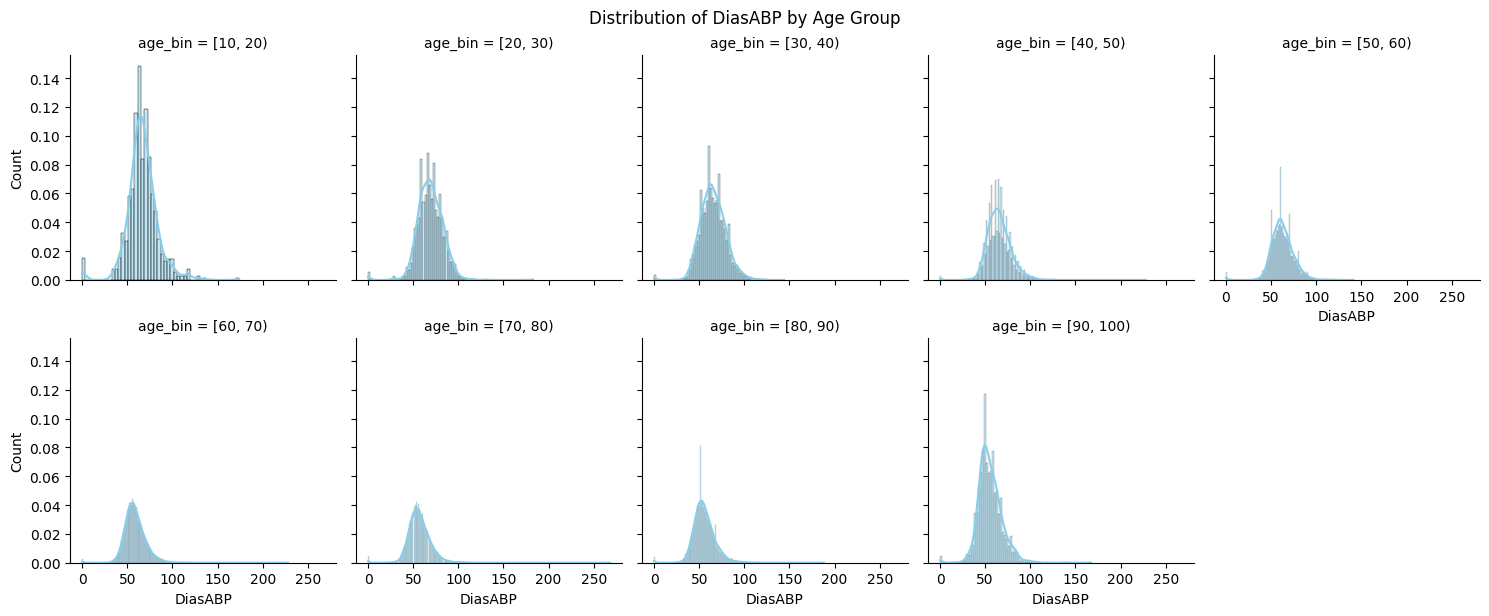

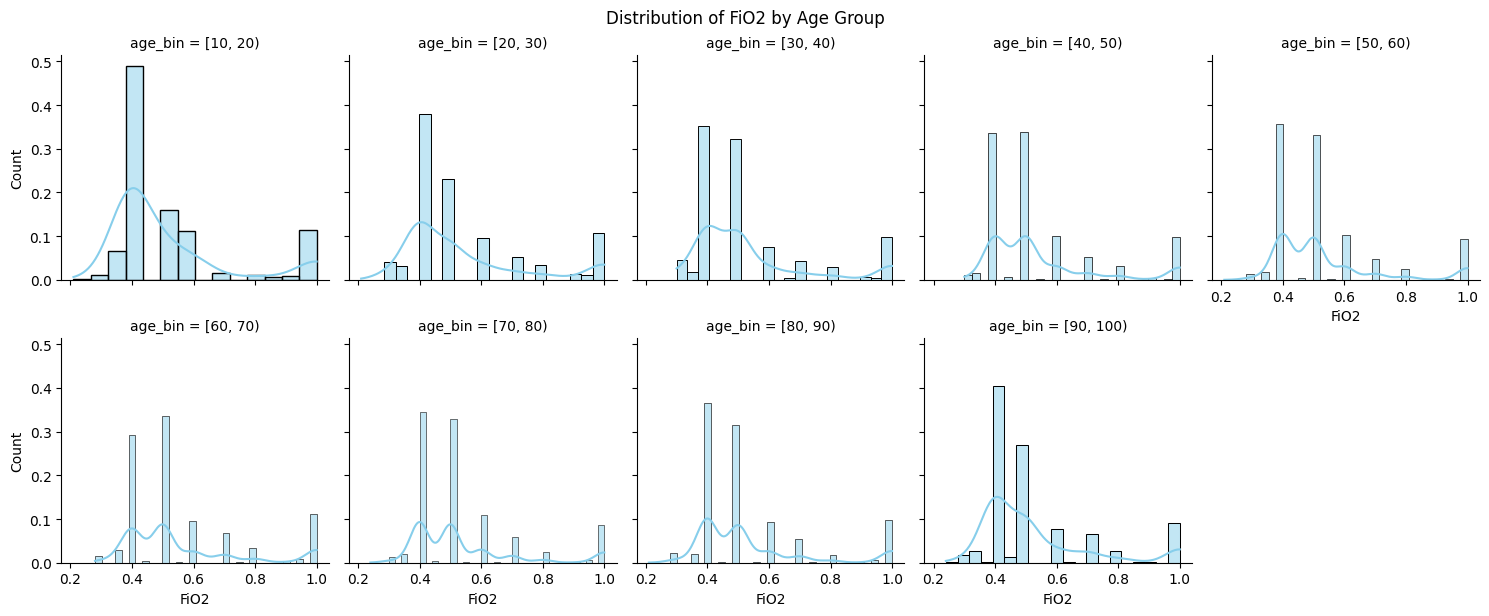

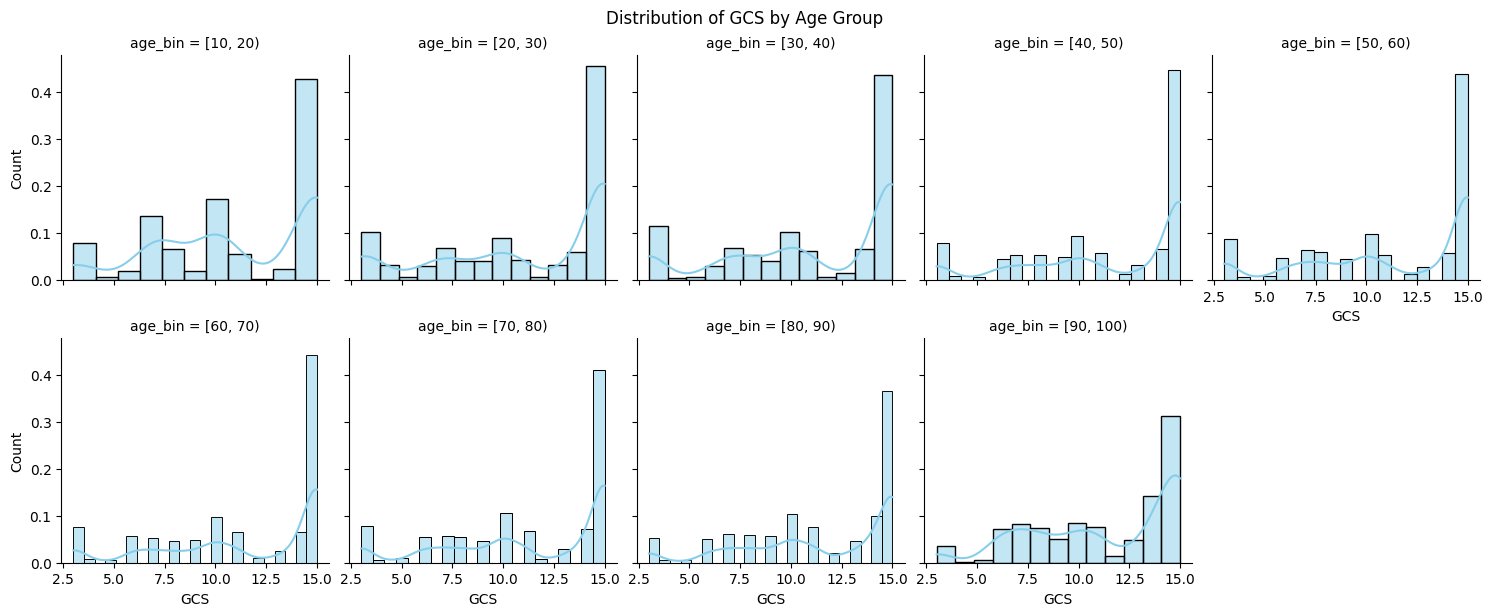

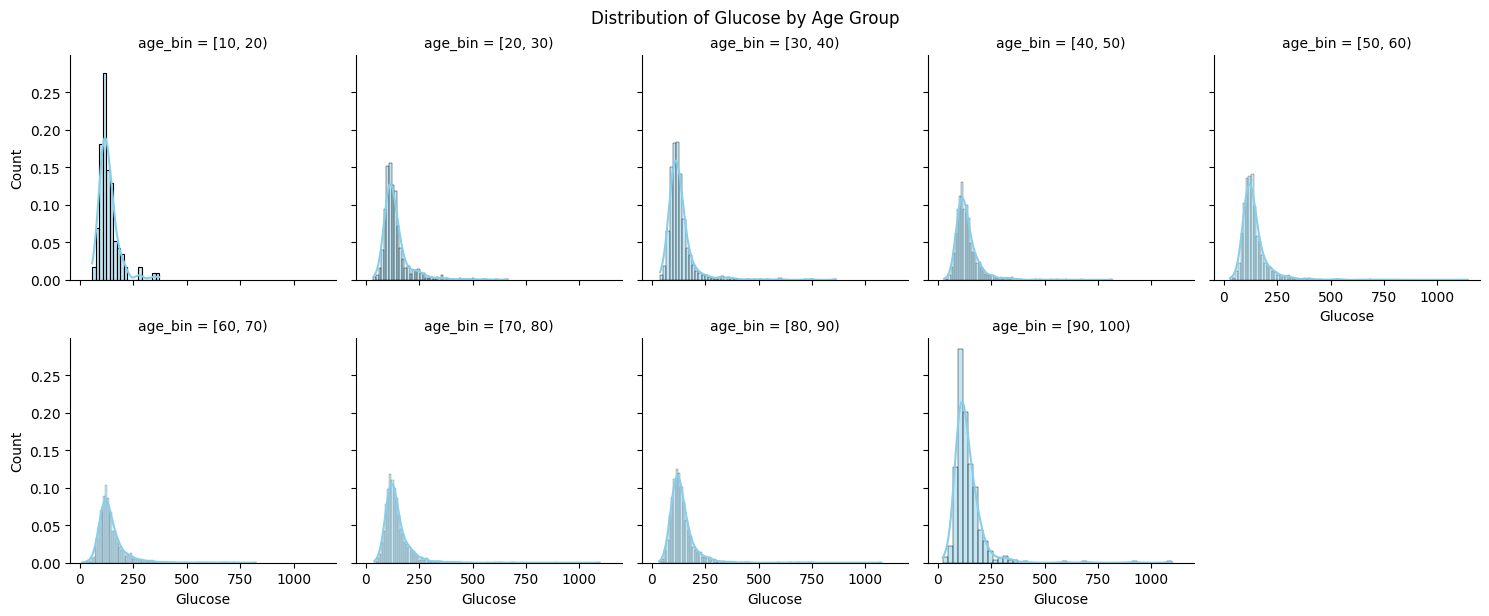

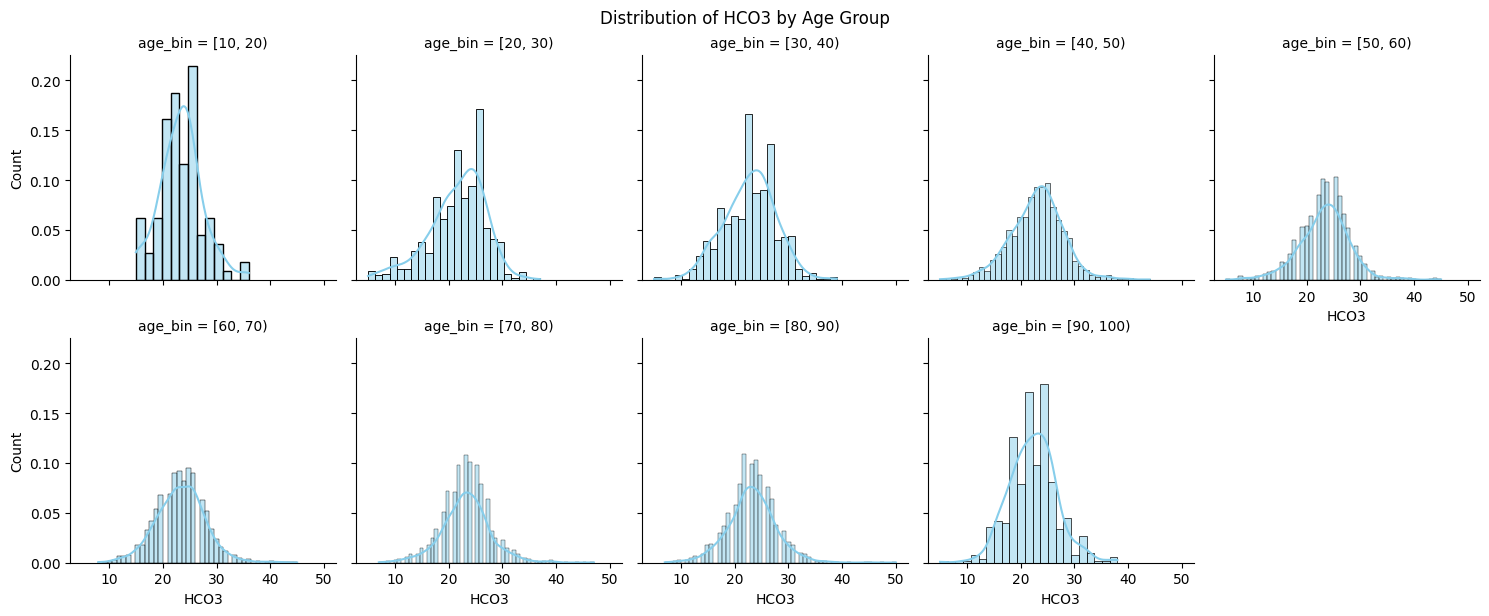

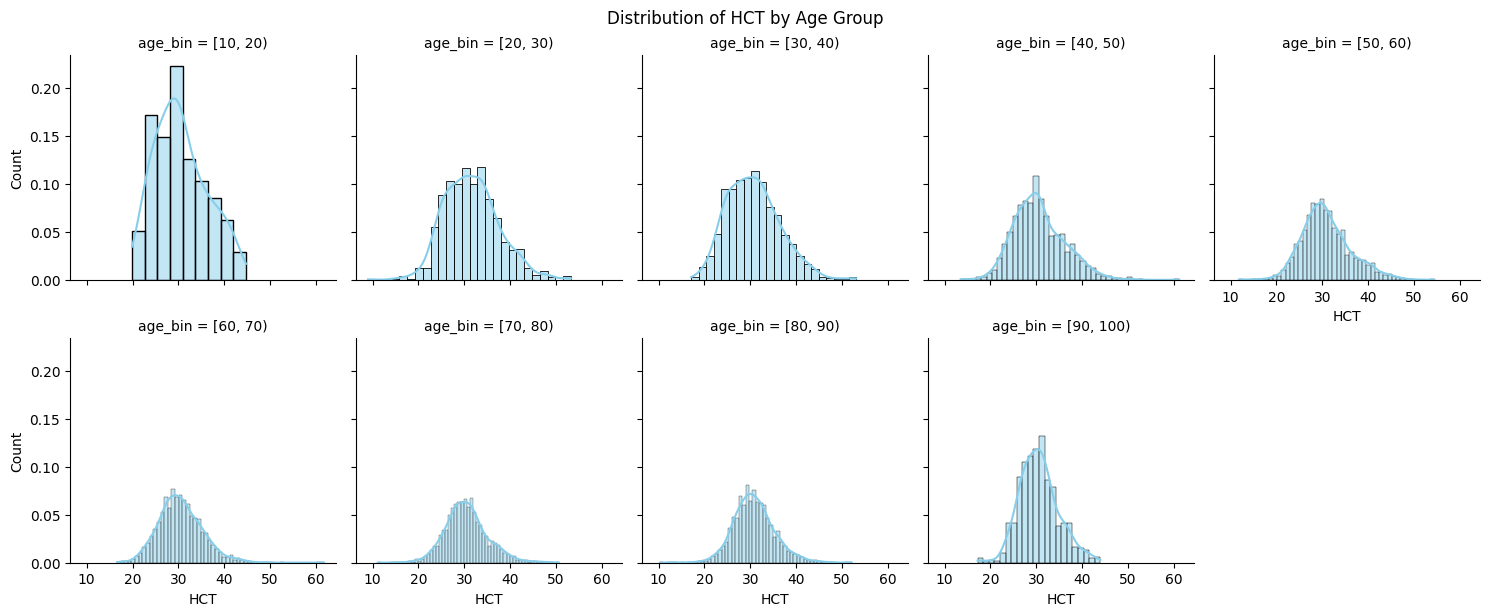

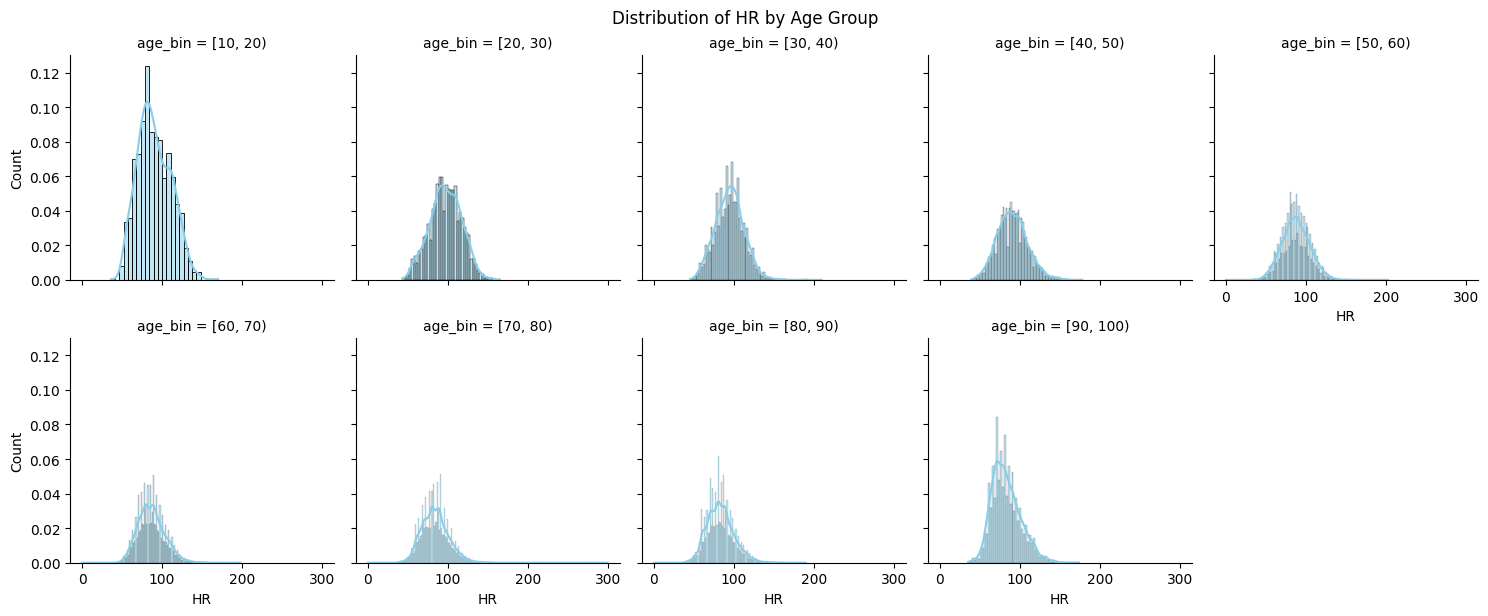

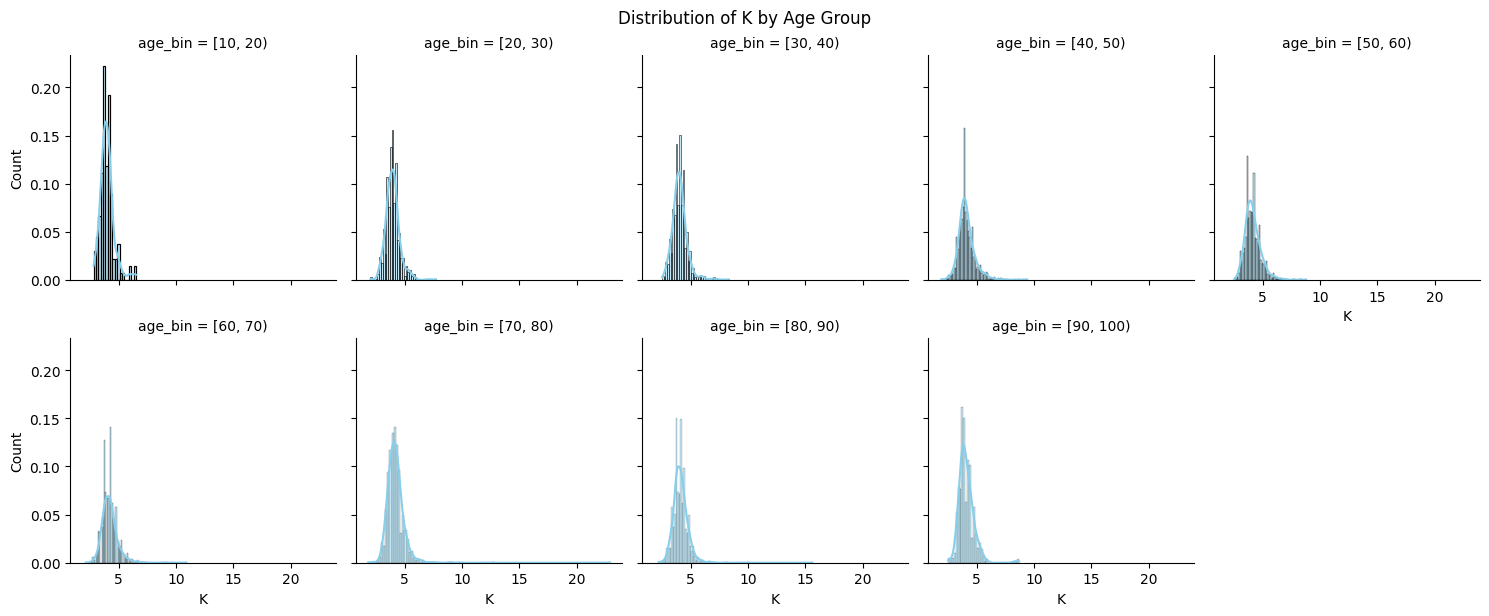

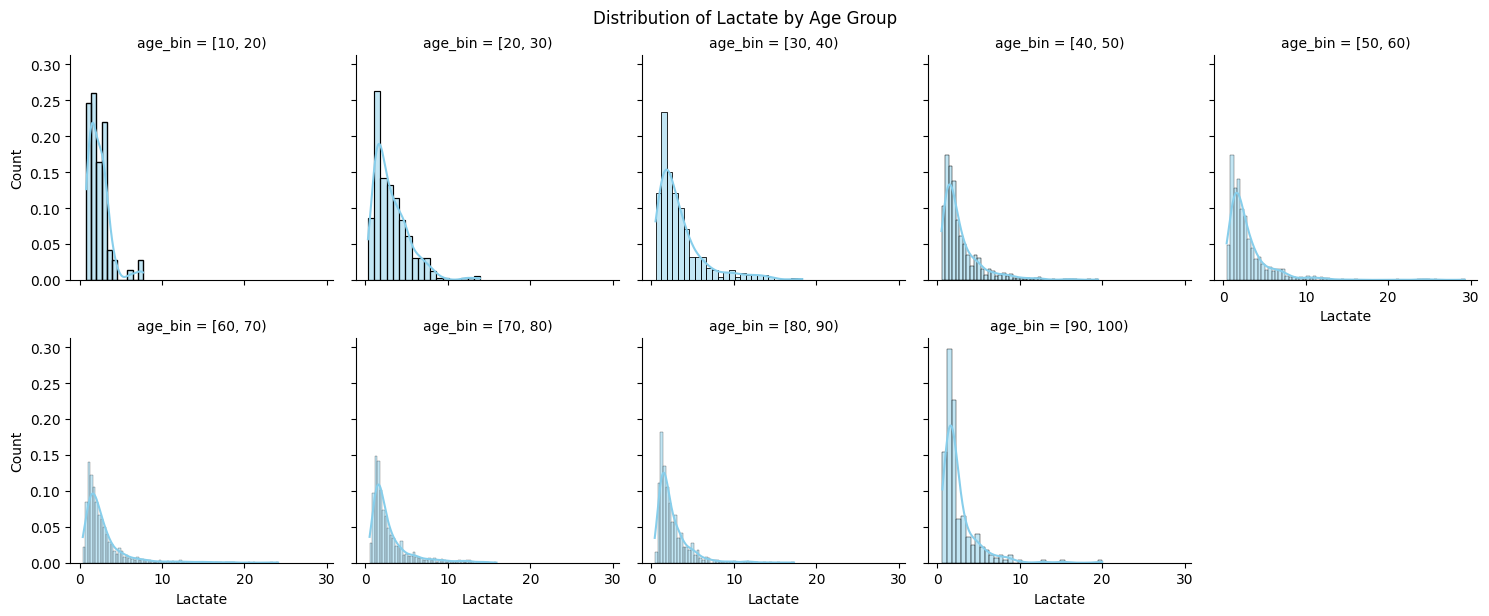

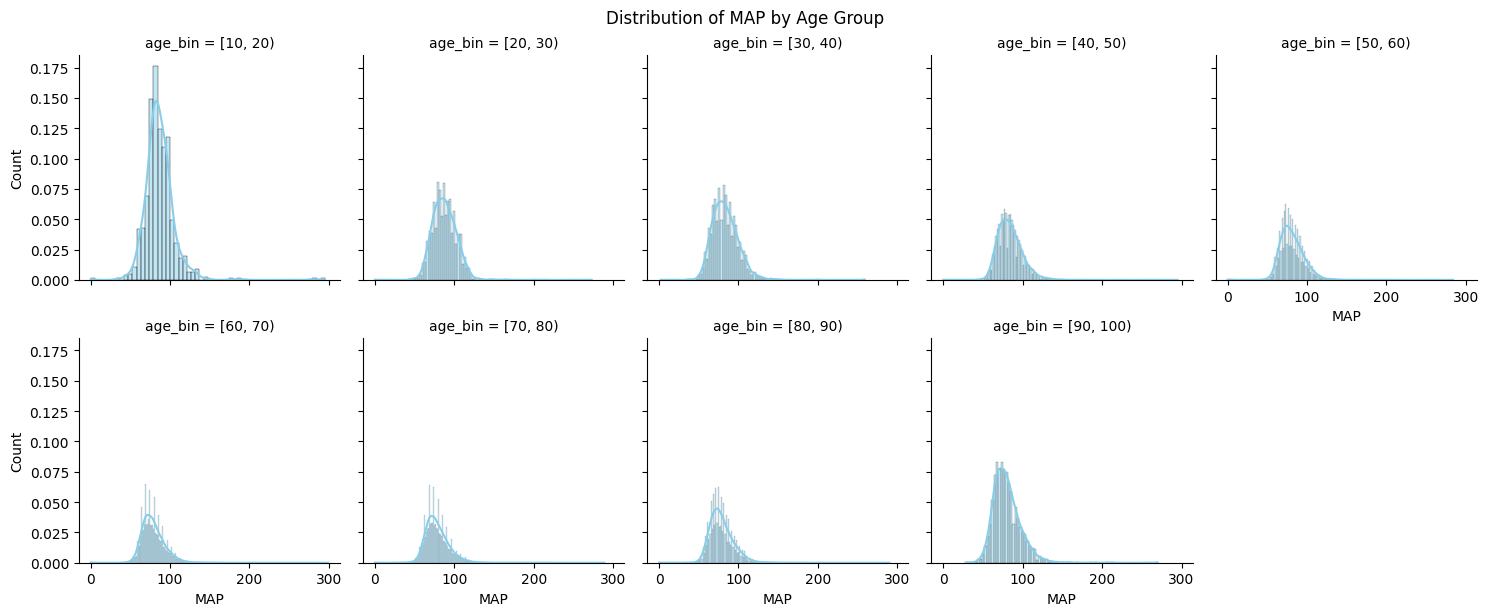

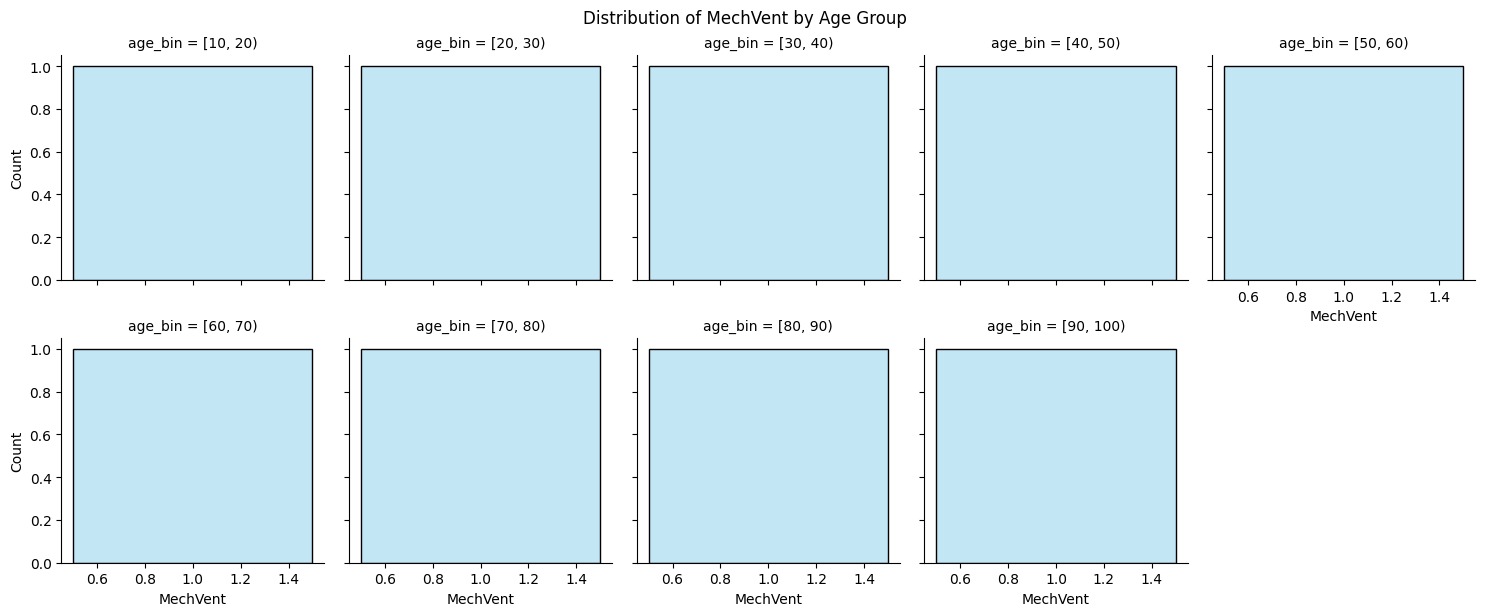

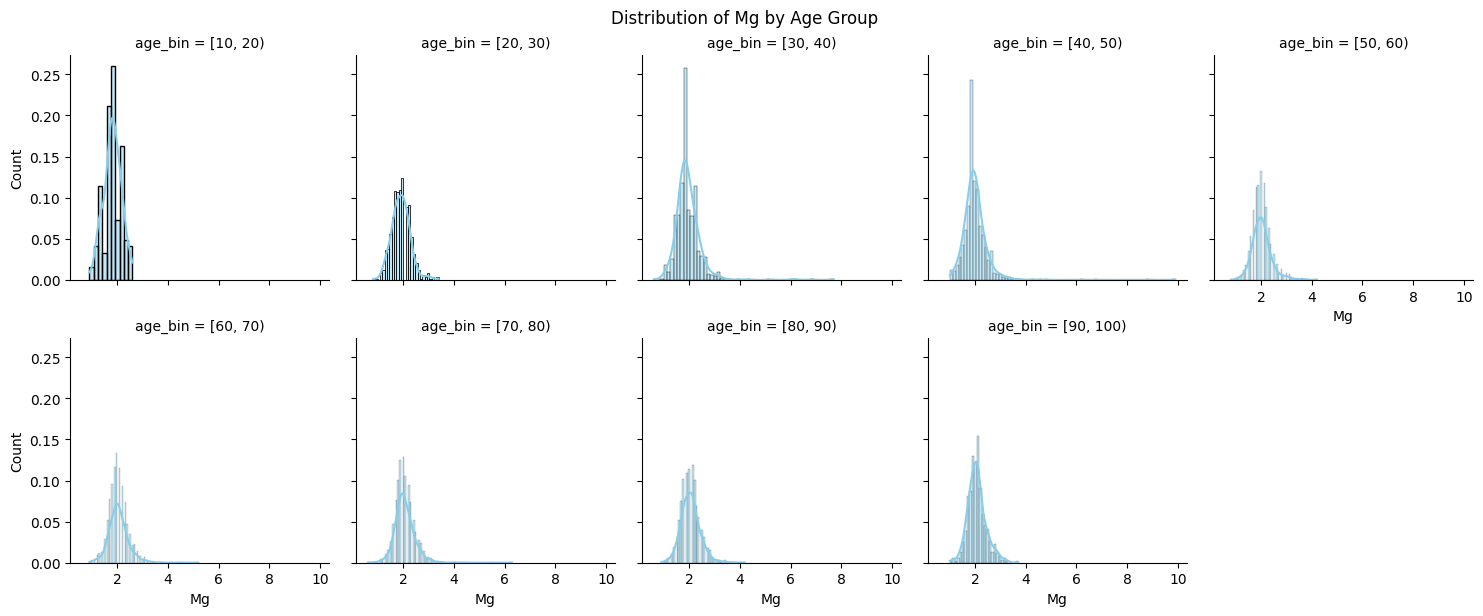

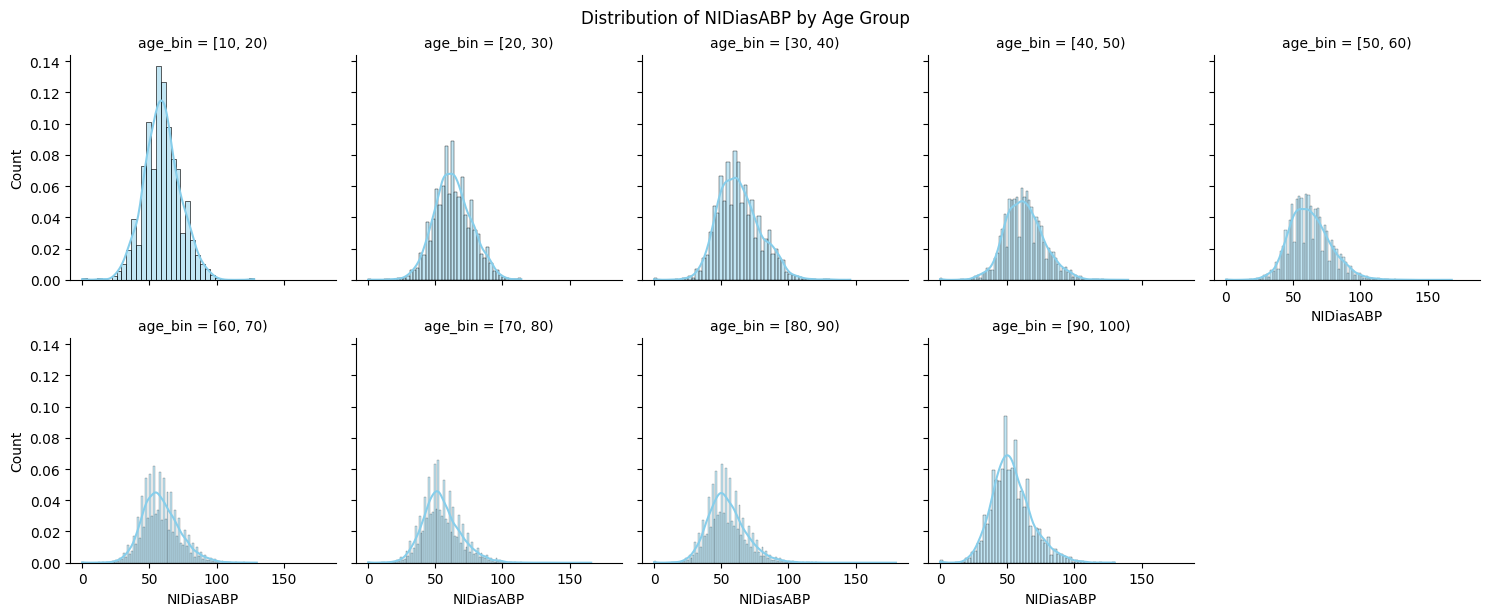

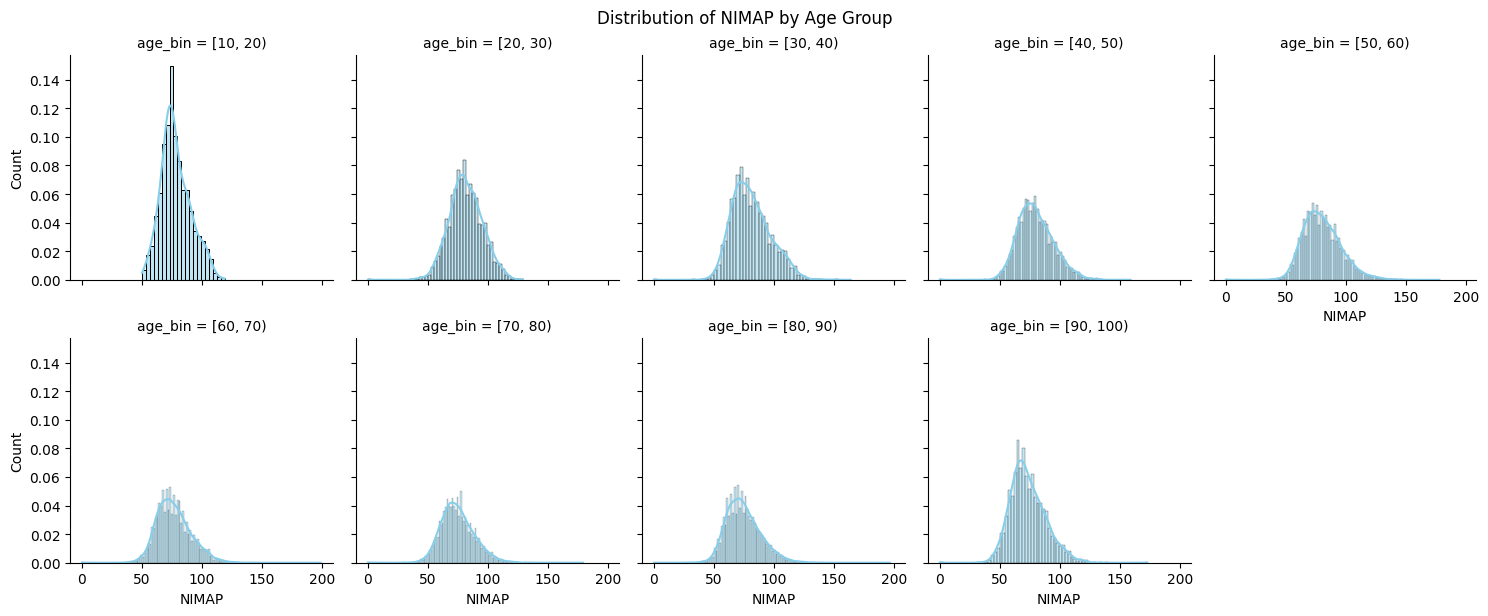

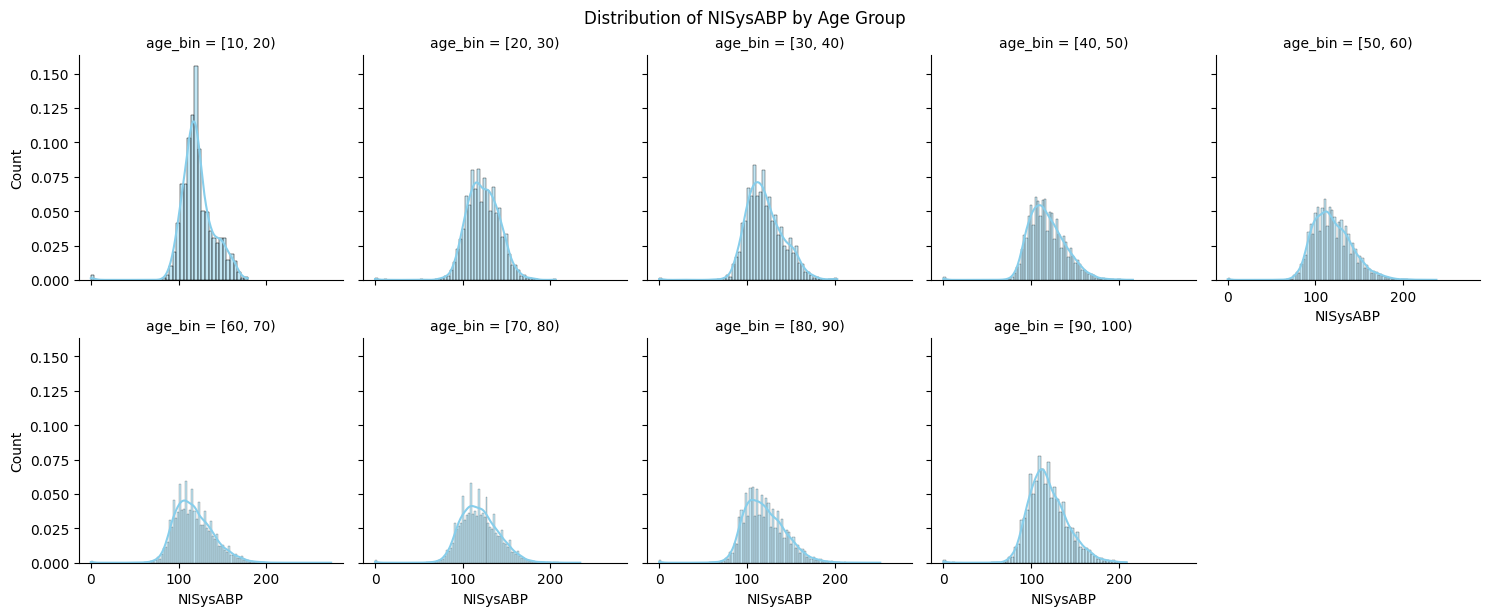

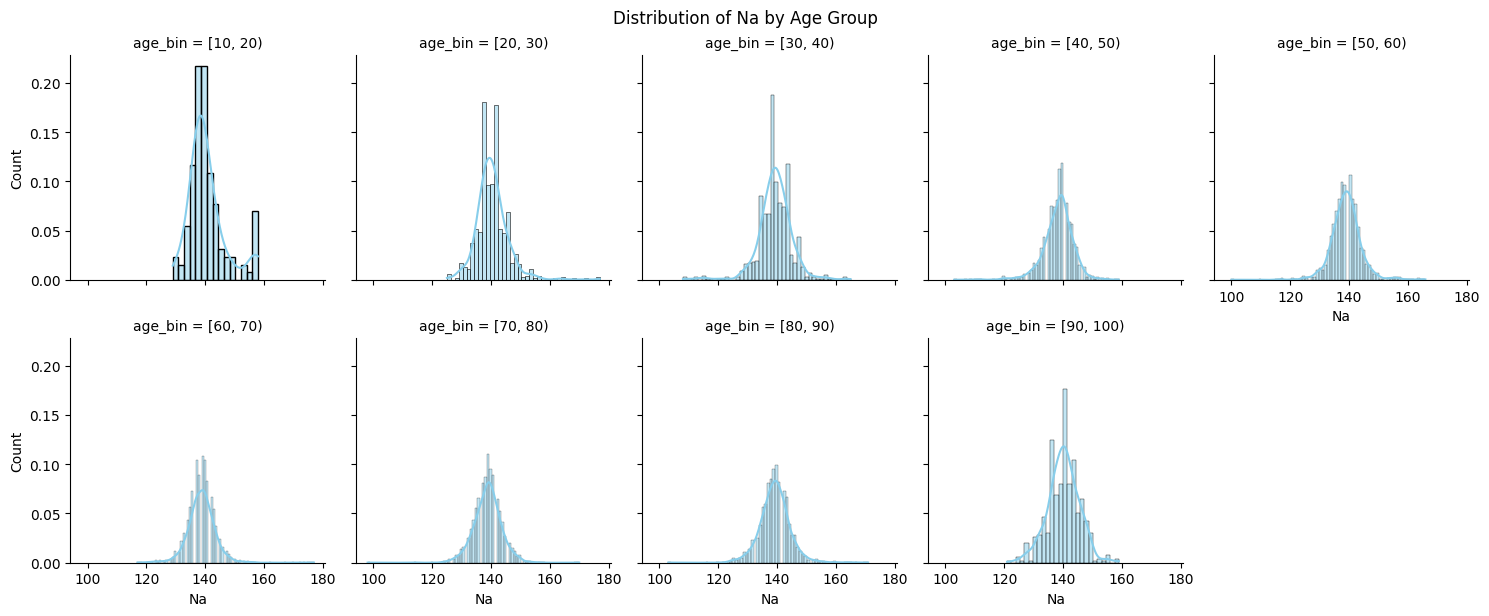

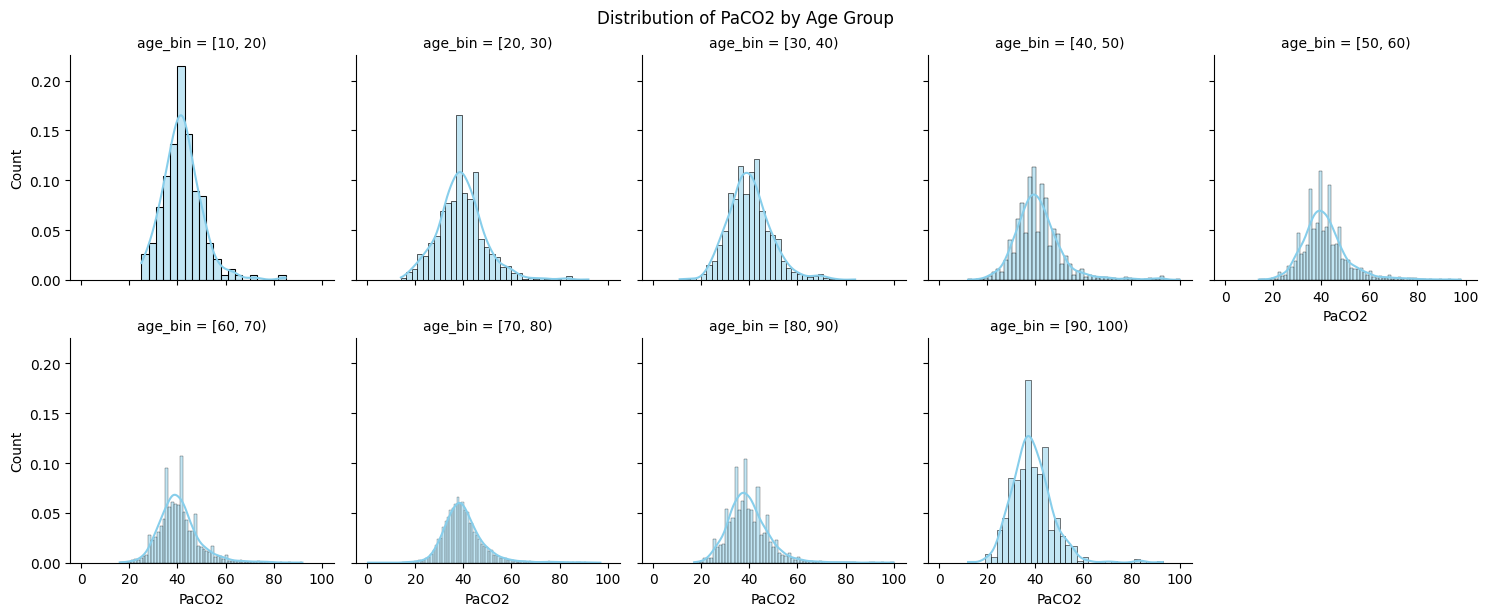

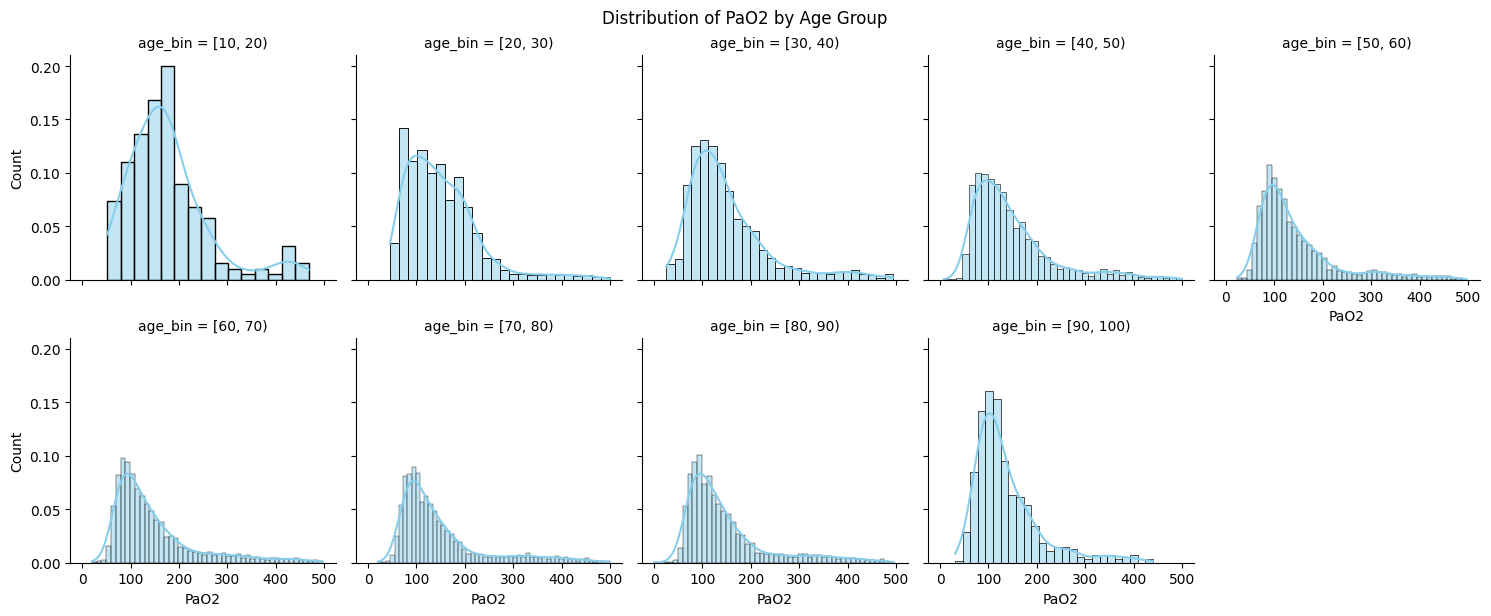

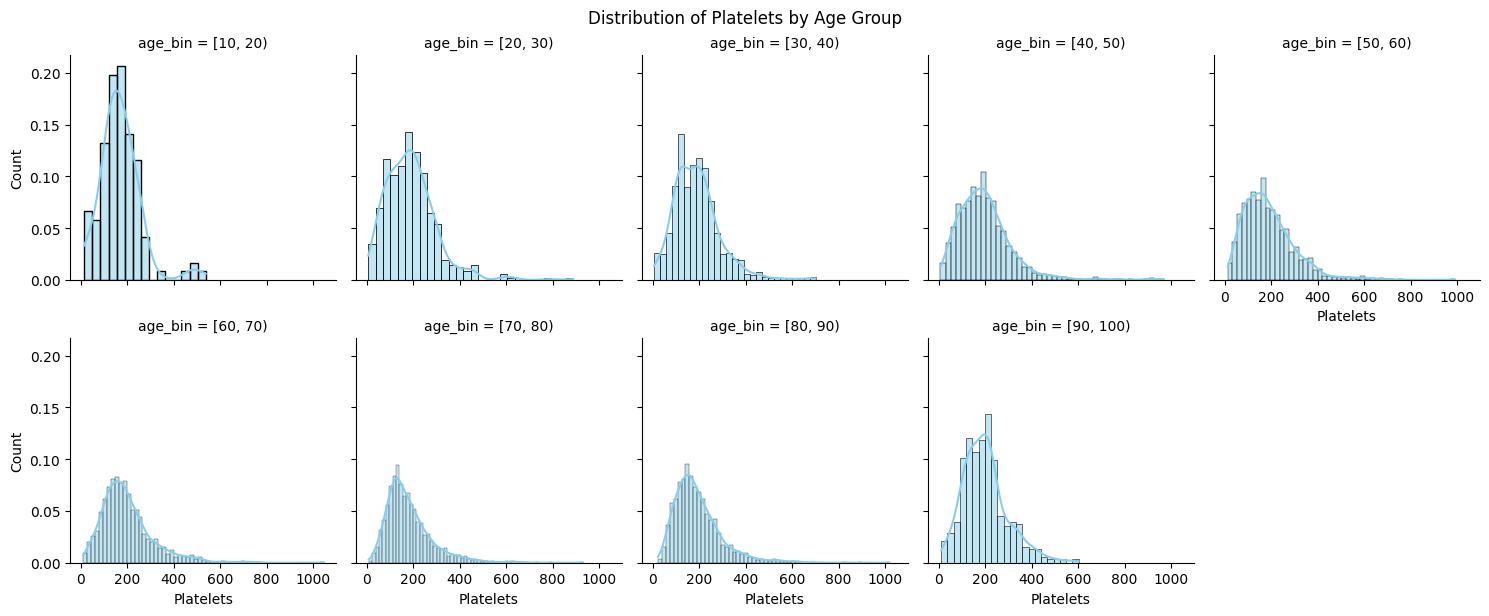

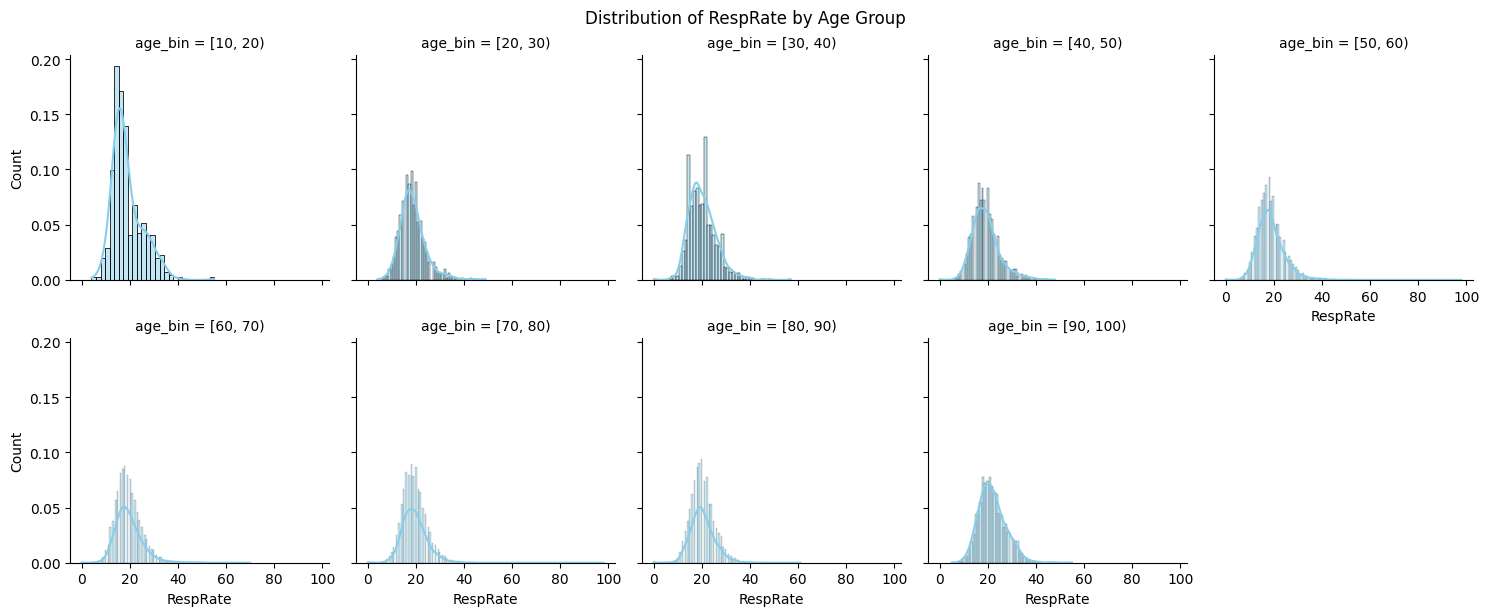

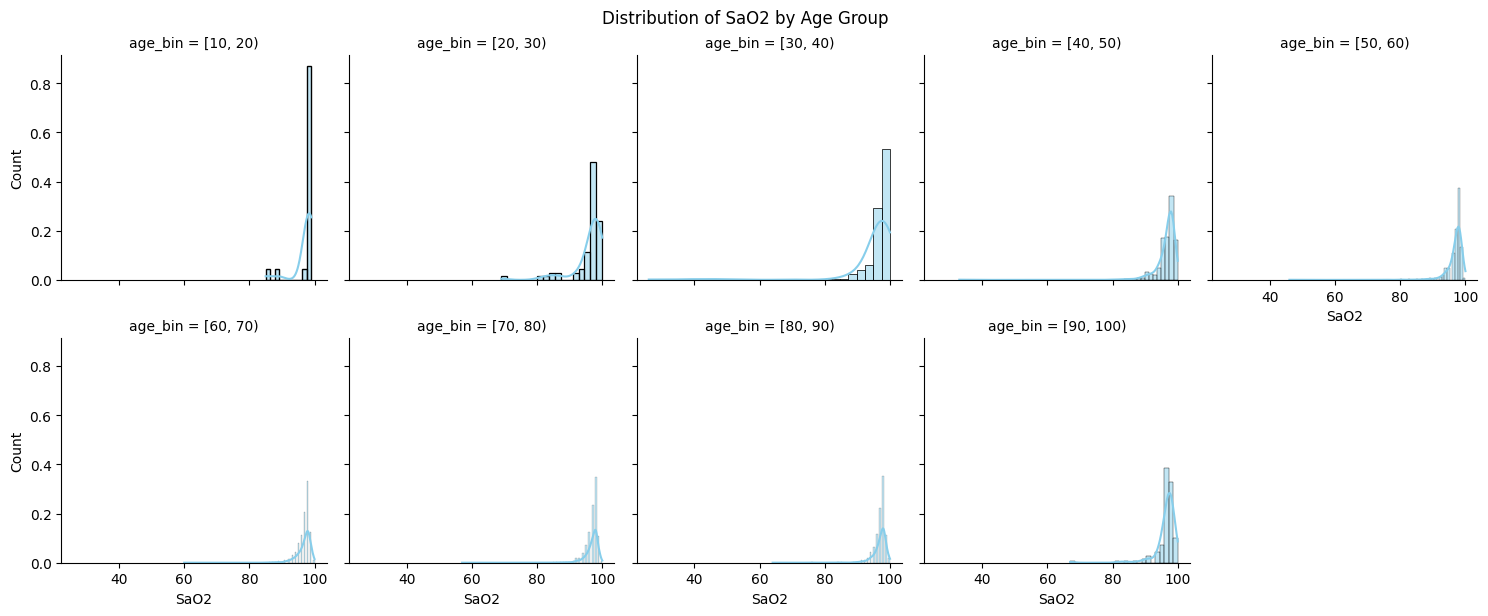

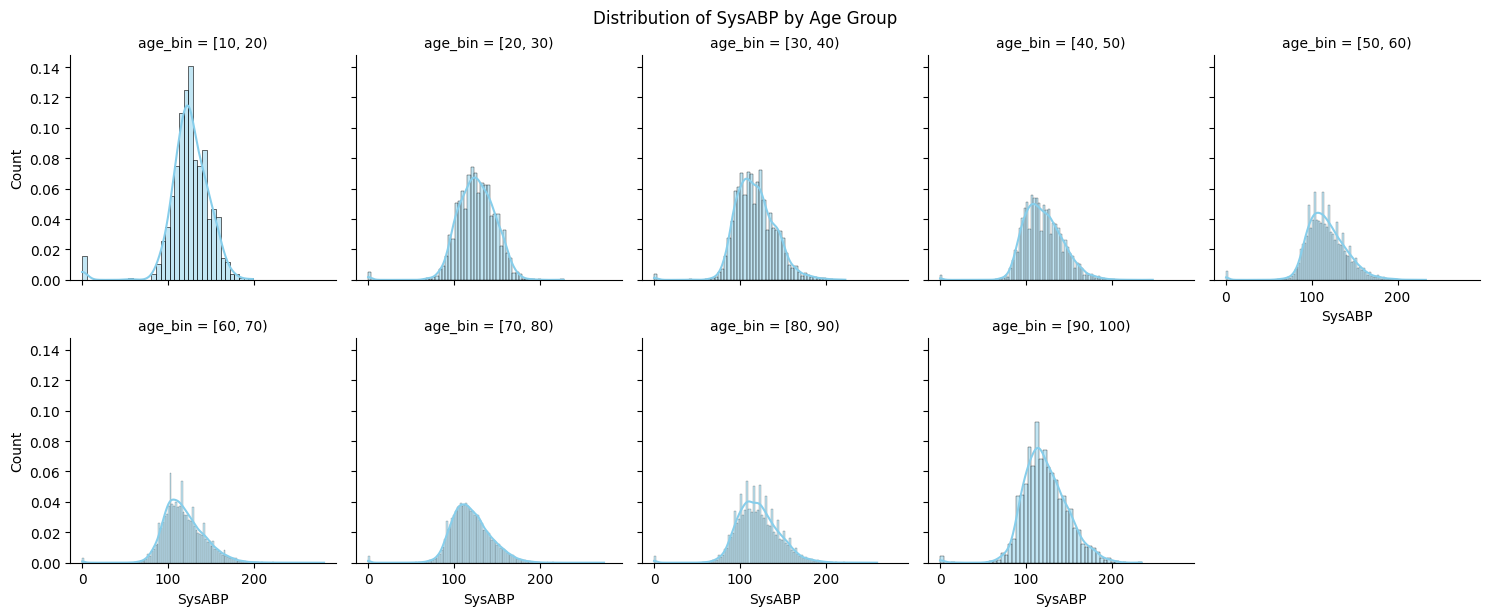

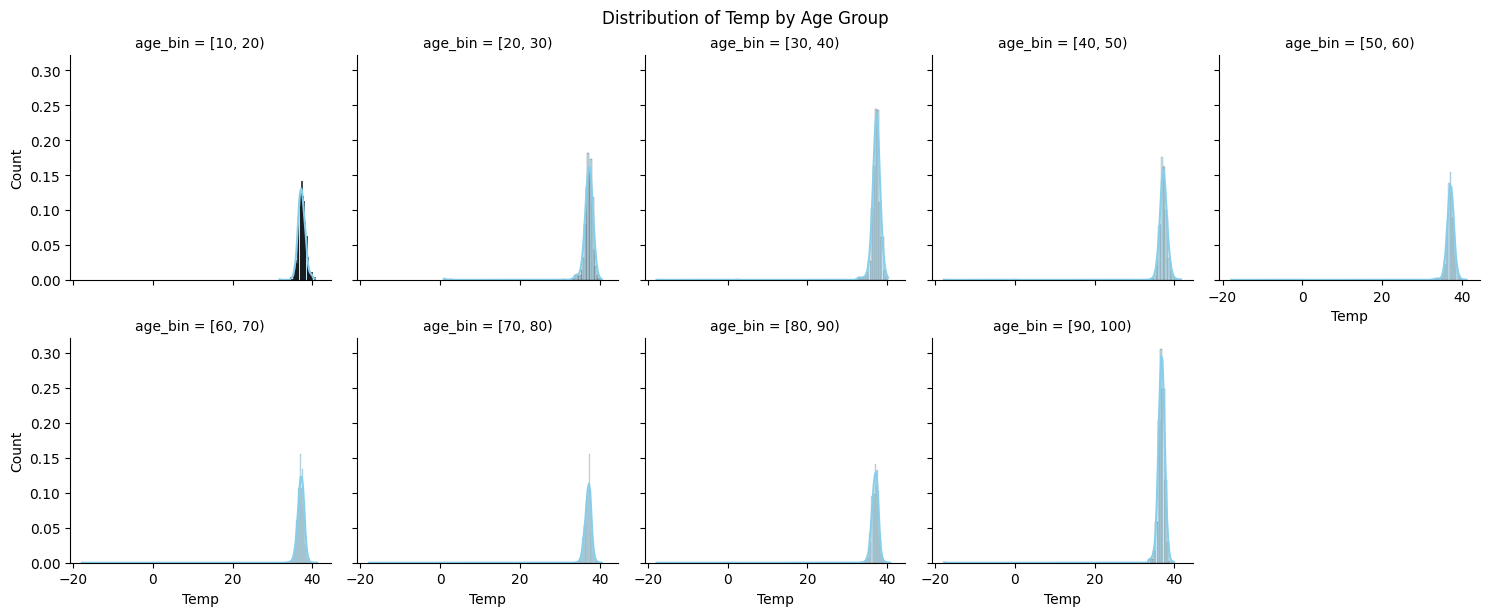

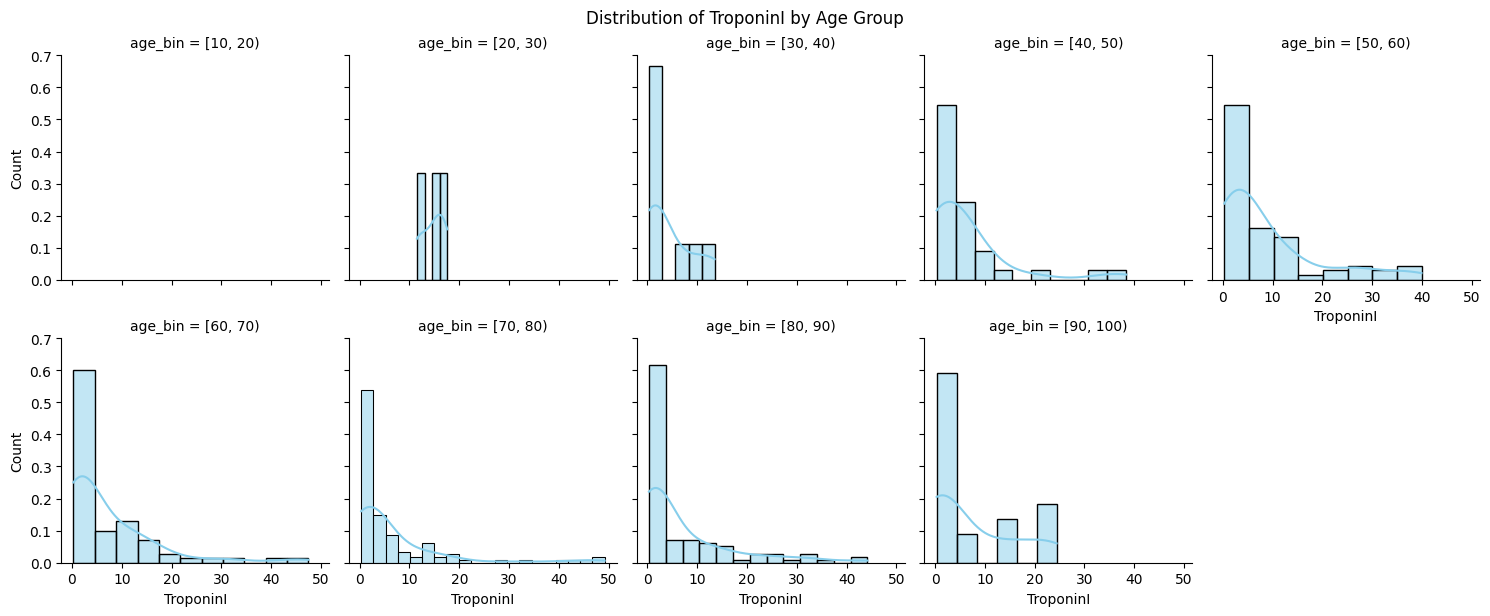

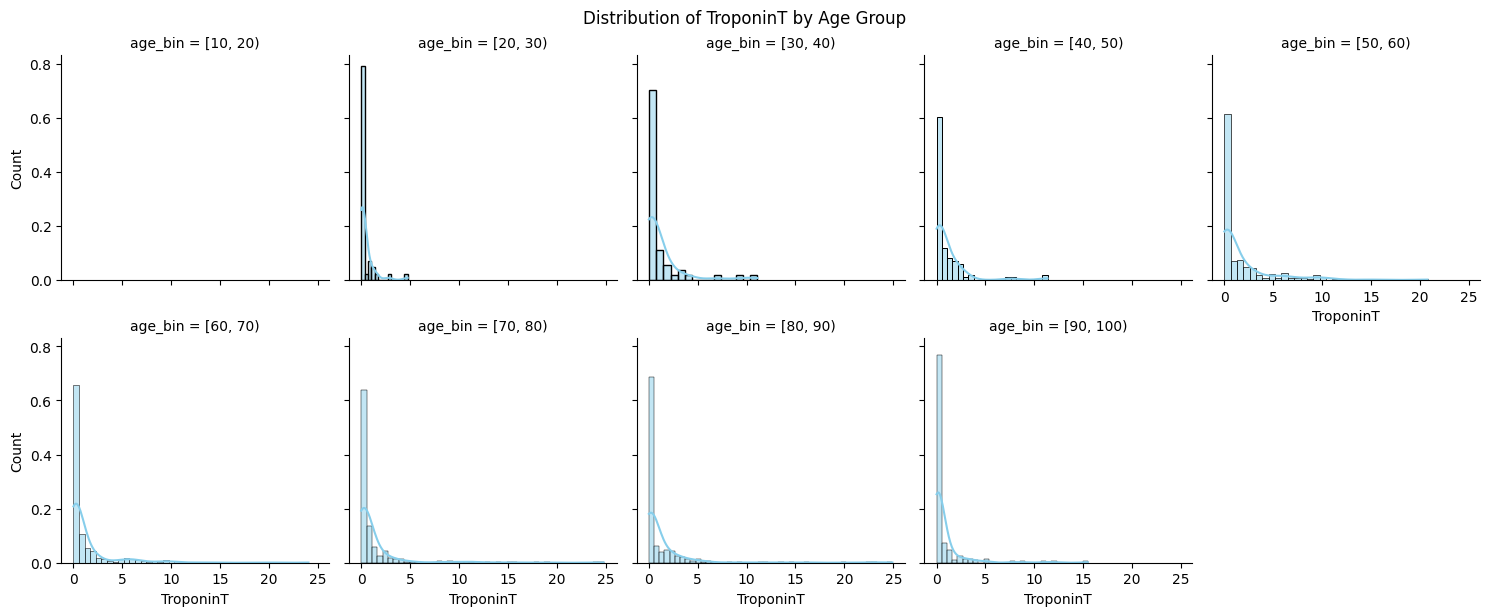

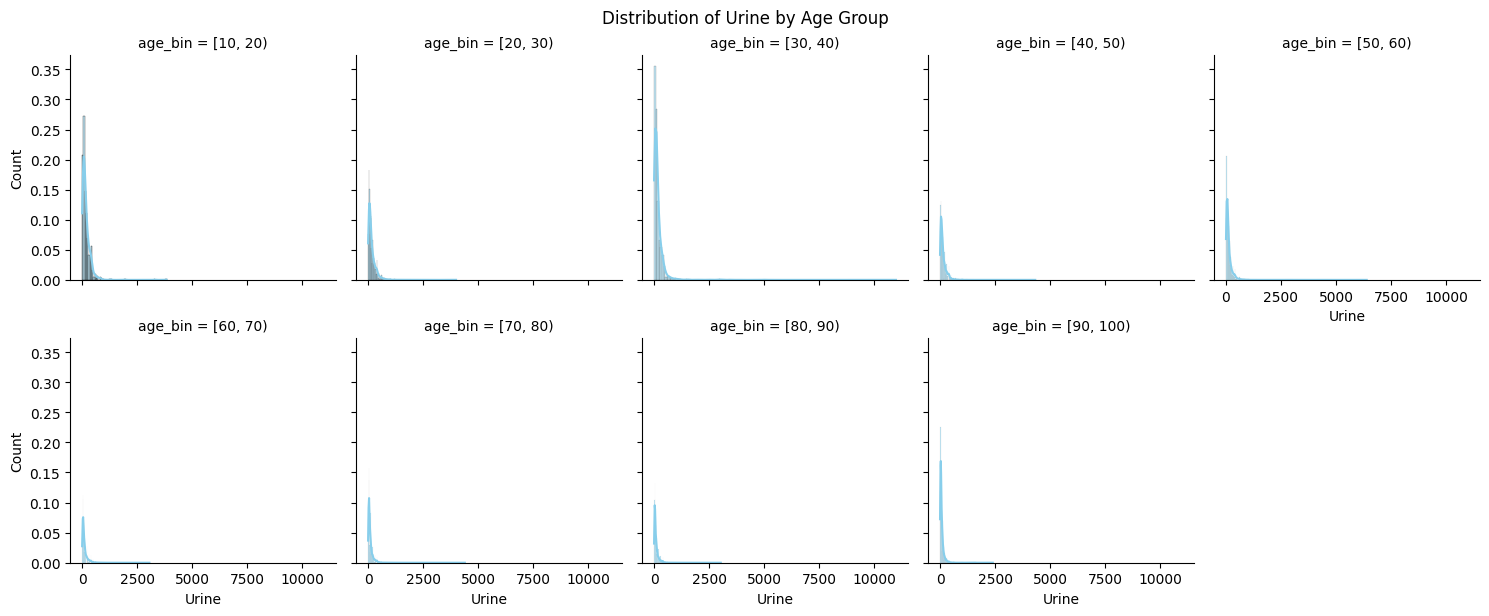

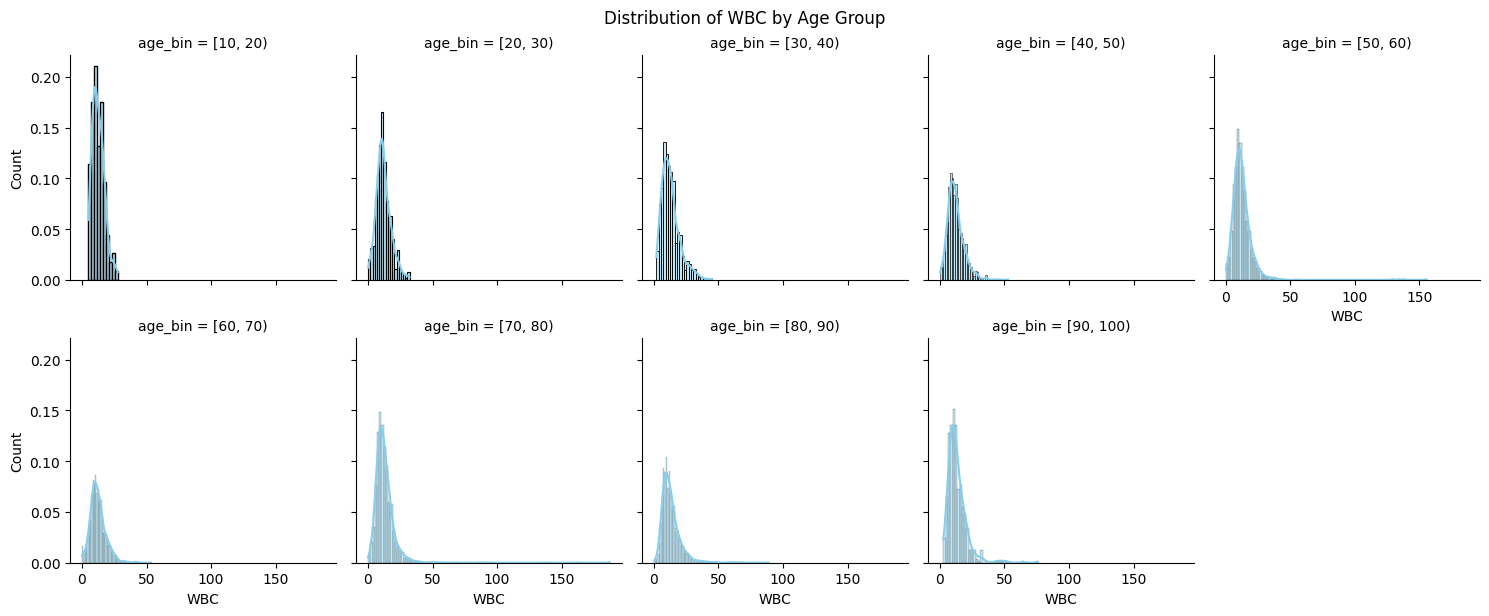

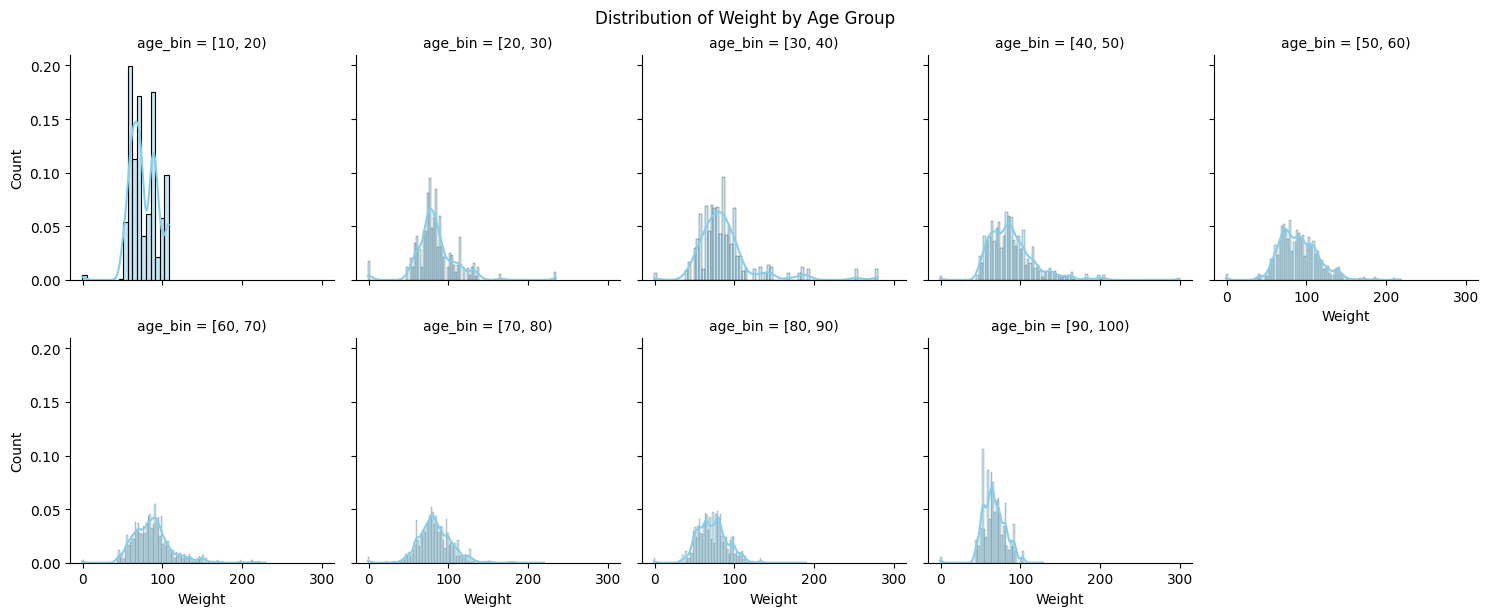

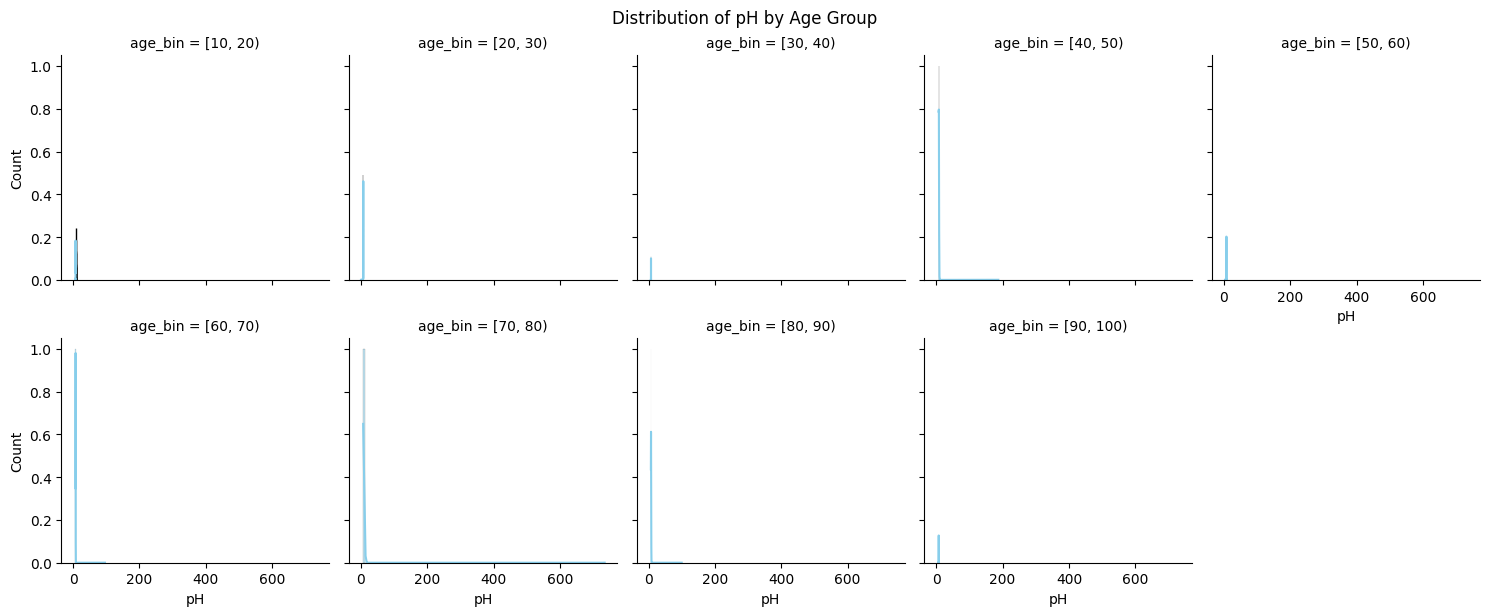

In [29]:
#Create the 10 year bins for ages
df_a = pd.read_parquet("processed/set_a.parquet")
# for i in range(len(df_a)):
#     a = 0
#     b = a+10
#     for j in range(0, 11):
#         if df_a["age"].iloc[i] in range(a, b):
#             f'mean_age'a= df_a["age"].mean()
bins = range(10, 101, 10)
df_a['age_bin'] = pd.cut(df_a['Age'], bins=bins, right=False)

mean_ages_df = df_a.groupby('age_bin', observed=False)[DYNAMIC_VARS].mean()
print(mean_ages_df)

#Plot for difference
import seaborn as sns
import matplotlib.pyplot as plt

# We loop through each variable you want to study
for var in DYNAMIC_VARS:
    # Create a "Grid" where each row/column is an age bin
    g = sns.FacetGrid(df_a, col="age_bin", col_wrap=5, sharex=True)

    # Map a histogram onto every square in that grid
    g.map(sns.histplot, var, kde=True, stat="probability", color="skyblue")

    g.set_axis_labels(var, "Count")
    g.fig.suptitle(f"Distribution of {var} by Age Group", y=1.02)
    plt.show()


